In [1]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine = fetch_ucirepo(id=109) 
  
# data (as pandas dataframes) 
X = wine.data.features 
y = wine.data.targets 


## Variables del conjunto de datos *Wine*

El conjunto de datos **Wine** contiene información química de distintas muestras de vino.  
Cada observación pertenece a una de **tres clases de vino**, y se describe mediante varias variables numéricas.

---

### Variable objetivo

- **class**  
  Clase del vino (variable categórica).  
  Indica el tipo de vino al que pertenece cada muestra (tres clases diferentes).

---

### Variables explicativas (características químicas)

1. **Alcohol**  
   Porcentaje de alcohol del vino.

2. **Malicacid**  
   Cantidad de ácido málico presente en el vino. El ácido málico influye en la acidez y el sabor.

3. **Ash**  
   Contenido de cenizas del vino. Representa el residuo mineral que queda tras la combustión.

4. **Alcalinity_of_ash**  
   Alcalinidad de las cenizas. Indica el carácter básico de los minerales presentes.

5. **Magnesium**  
   Concentración de magnesio en el vino (mg/L). Es un mineral relacionado con la composición del suelo.

6. **Total_phenols**  
   Contenido total de compuestos fenólicos. Los fenoles influyen en el sabor, color y propiedades antioxidantes.

7. **Flavanoids**  
   Cantidad de flavonoides. Son un tipo específico de compuestos fenólicos relacionados con el color y el cuerpo del vino.

8. **Nonflavanoid_phenols**  
   Fenoles no flavonoides. Representan otros compuestos fenólicos distintos de los flavonoides.

9. **Proanthocyanins**  
   Contenido de proantocianidinas. Contribuyen a la astringencia y estructura del vino.

10. **Color_intensity**  
    Intensidad del color del vino. Mide cuán oscuro o concentrado es el color.

11. **Hue**  
    Tono del color del vino. Relacionado con la tonalidad (más rojiza, amarillenta, etc.).

12. **OD280_OD315_of_diluted_wines**  
    Relación de absorbancias ópticas a 280 nm y 315 nm. Se utiliza como indicador de la calidad y concentración de compuestos fenólicos.

13. **Proline**  
    Cantidad de prolina (aminoácido) presente en el vino. Está relacionada con la maduración y el tipo de uva.

---

### Nota para el análisis con K-means

Todas las variables explicativas son **numéricas**, pero se encuentran en **escalas muy diferentes** (por ejemplo, *Alcohol* frente a *Proline*).  
Por este motivo, es **imprescindible aplicar una estandarización previa** antes de utilizar algoritmos basados en distancias como **K-means**.


In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df = pd.DataFrame(X) # Construimos un dataframe con las columnas del dataframe X
df[y.columns] = y  # agregamos la columna y al dataframe

In [4]:
df

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [5]:
df.info() # información del dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
 13  class

In [6]:
# Identifica y muestra numéricamente los valores NaN de este dataset en orden descendente.
nulos = df.isna().sum().sort_values(ascending=False)
nulos

Alcohol                         0
Malicacid                       0
Ash                             0
Alcalinity_of_ash               0
Magnesium                       0
Total_phenols                   0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 0
Color_intensity                 0
Hue                             0
0D280_0D315_of_diluted_wines    0
Proline                         0
class                           0
dtype: int64

In [7]:
predictoras = X.columns # lista de las variables predictoras. 
print(predictoras)

Index(['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
       'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
       'Proanthocyanins', 'Color_intensity', 'Hue',
       '0D280_0D315_of_diluted_wines', 'Proline'],
      dtype='object')


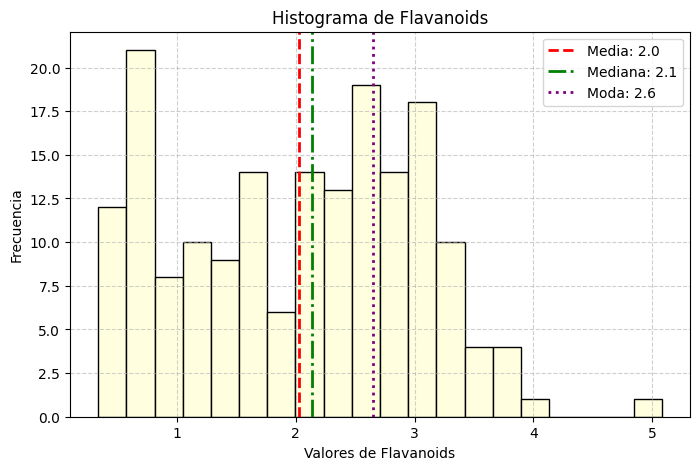

In [8]:
# Construye una función que, dado un dataframe y una cadena con el nombre de una variable, muestre un histograma de una variable predictora,
# y líneas de colores para representar la media, la mediana y la moda.Toma nota de las posibles asimetrías de las variables.
#plt.style.use('default')  # estilo de los gráficos por defecto en matplolib

def histograma(df, variable):    

    x = df[variable] # asignamos 'variable' a x

    # Calcular medidas estadísticas básicas
    media = x.mean()             # Media: valor promedio
    mediana = x.median()         # Mediana: valor central
    moda = x.mode()[0]           # Moda: valor más frecuente
    asimetria = x.skew()         # Asimetría (skewness): mide la simetría de la distribución

    # Crear el histograma
    plt.figure(figsize=(8,5))    # Define el tamaño del gráfico
    plt.hist(x,  # variable a utulizar en el histograma
             bins=20,  # número de columnas a utilizar en el histograma (por defecto 10)
             color='lightyellow', # color de las columnas
             edgecolor='black' # color del borde de las columnas
            )  

    # Añadir líneas verticales con las medidas estadísticas
    plt.axvline(media, color='red', linestyle='--', linewidth=2, 
                label=f'Media: {media:.1f}')
    plt.axvline(mediana, color='green', linestyle='-.', linewidth=2, 
                label=f'Mediana: {mediana:.1f}')
    plt.axvline(moda, color='purple', linestyle=':', linewidth=2, 
                label=f'Moda: {moda:.1f}')

    # Personalización del gráfico
    plt.title(f'Histograma de {variable}')
    plt.xlabel(f'Valores de {variable}')
    plt.ylabel('Frecuencia')
    plt.legend()                                         # Muestra las líneas con etiquetas
    plt.grid(True, linestyle='--', alpha=0.6)            # Cuadrícula para facilitar la lectura

    plt.show()                                           # Muestra el gráfico final

histograma(df,'Flavanoids') # llamada a la función

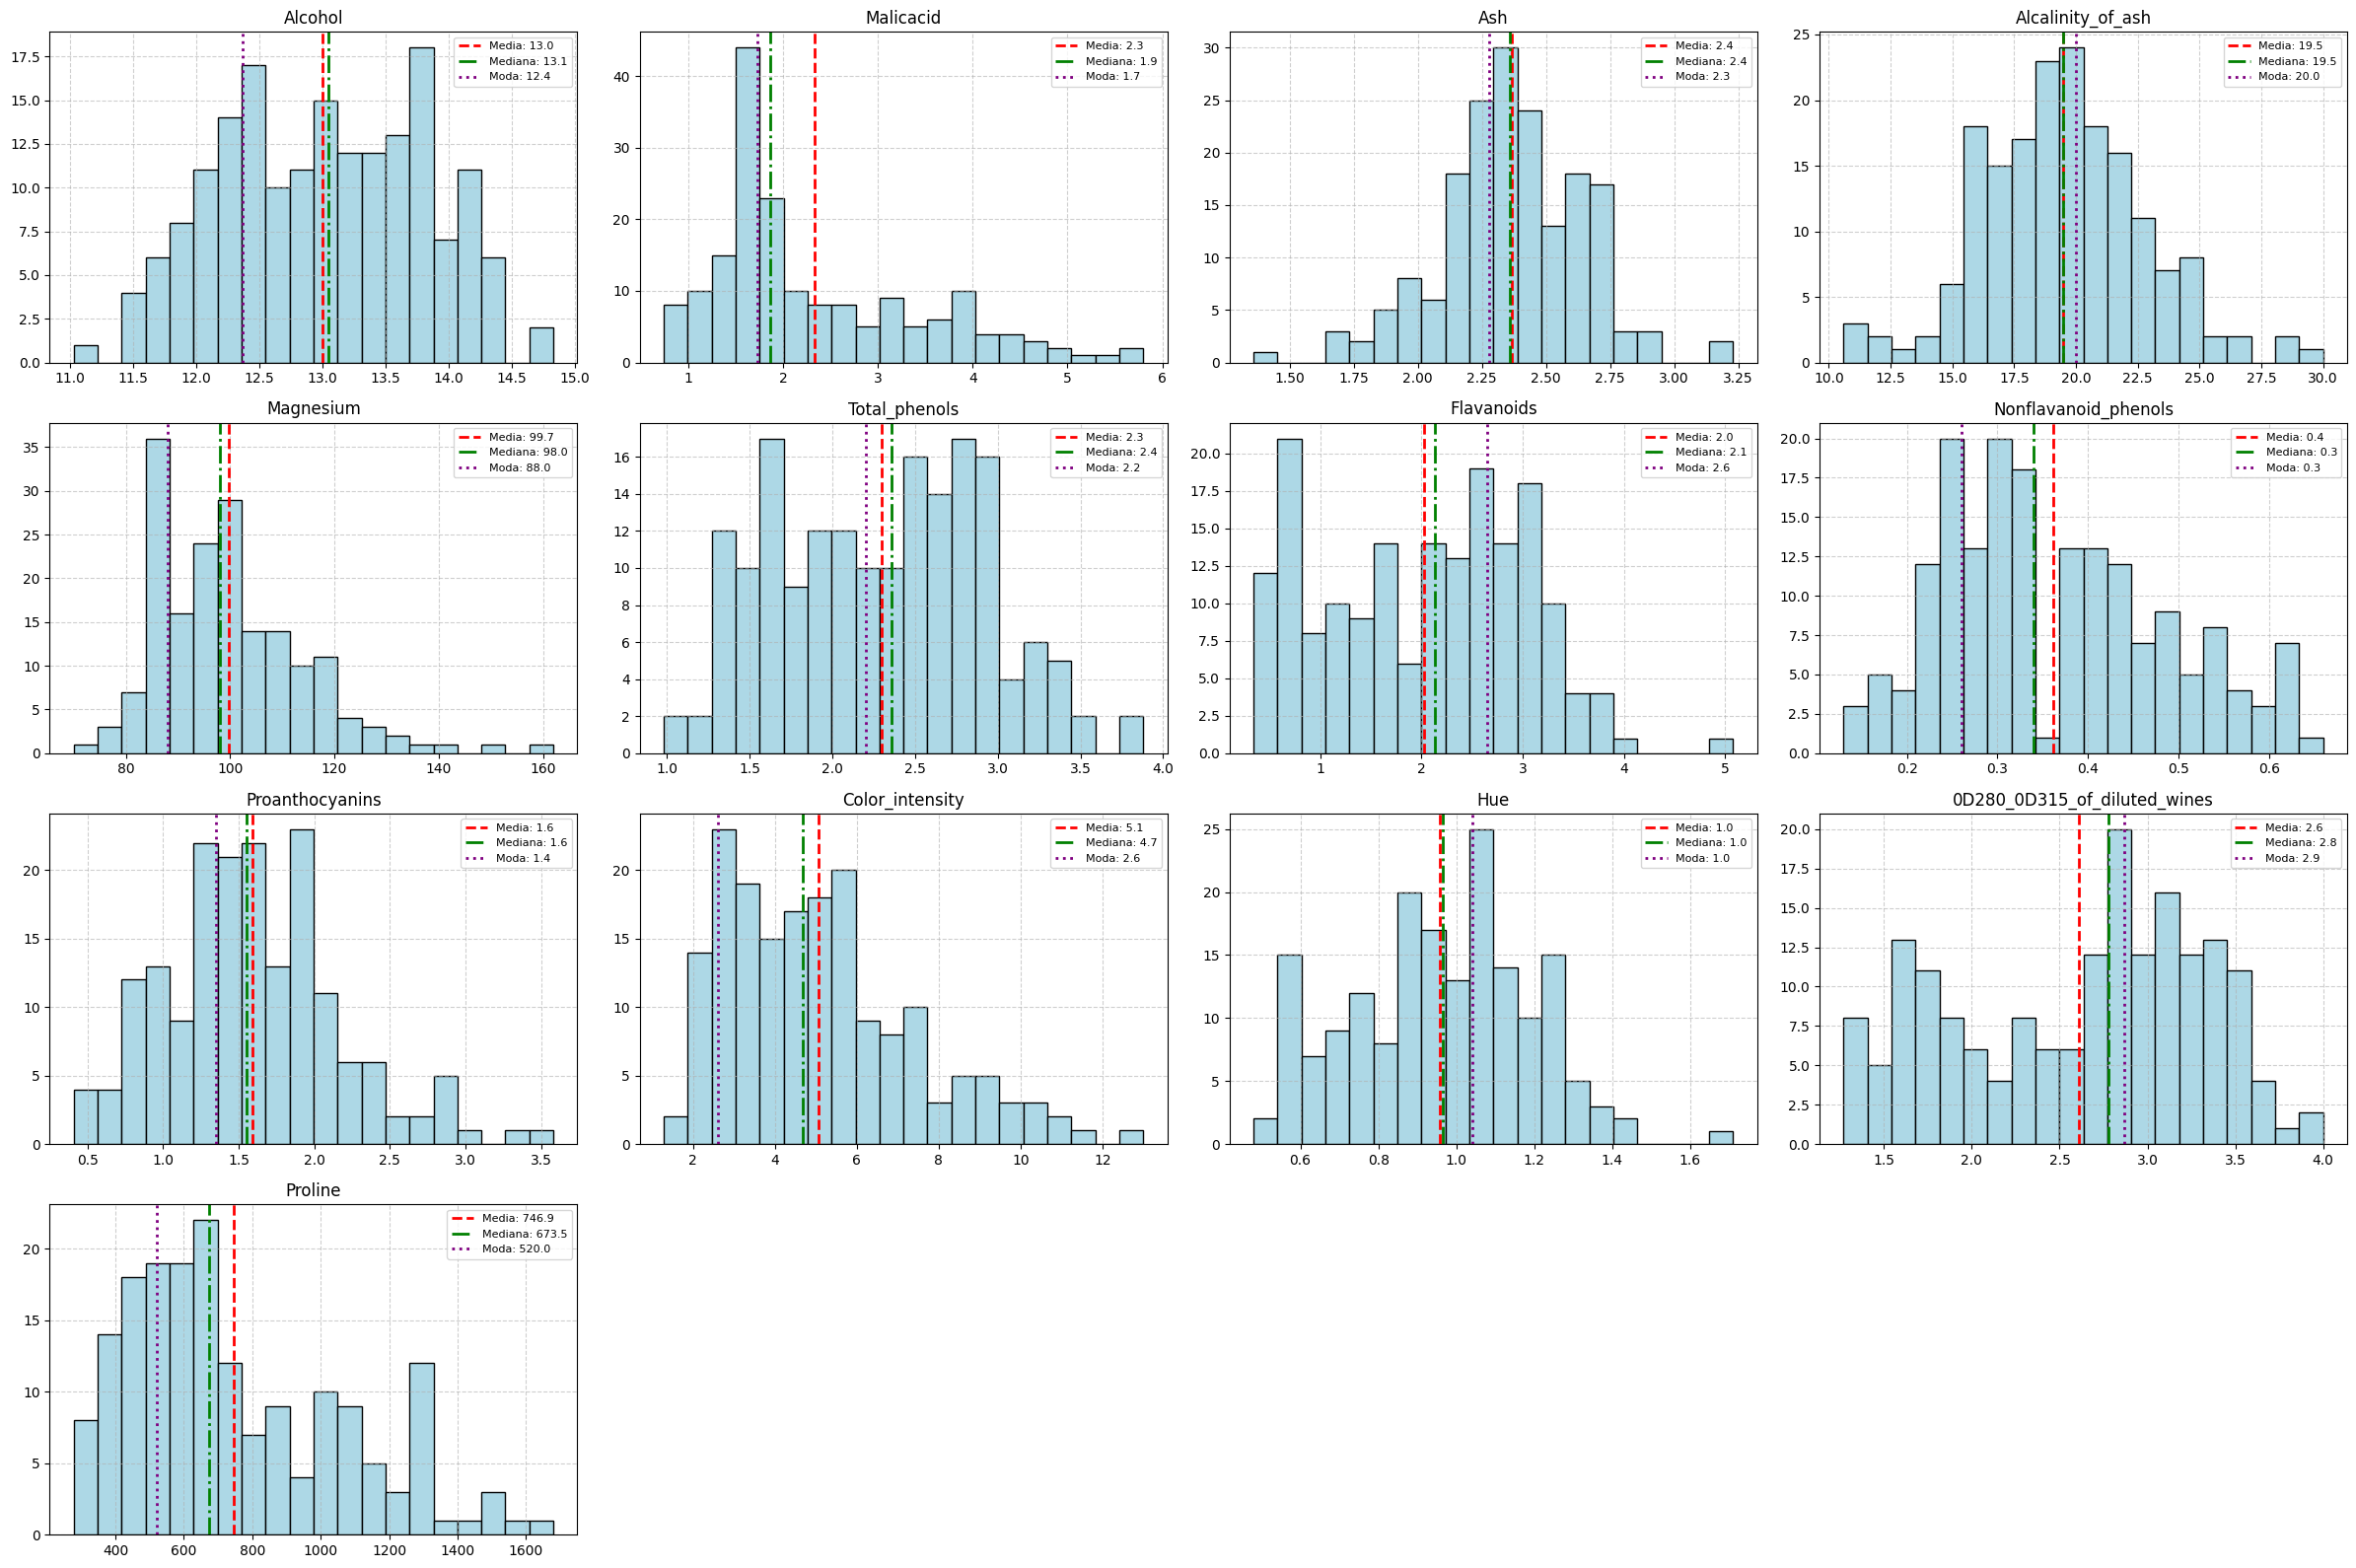

In [9]:
import matplotlib.pyplot as plt
import math


def histogramas(df, variables):
    """
    Crea una rejilla de histogramas con medidas estadísticas,  ajustando automáticamente el número de filas y columnas.
    """

    n_vars = len(variables) # número de variables a representar
    
    # Calcular número de filas y columnas automáticamente.
    # calcula el número de columnas para organizar n_vars elementos en una cuadrícula lo más cuadrada posible sin que falten huecos.
    # (puede sobrar alguno)
    columnas = math.ceil(math.sqrt(n_vars))  #raíz cuadrada del número de variables y redondeo hacia arriba al entero más cercano
    
    # calcula el número mínimo de filas necesarias para colocar todos los elementos cuando cada fila tiene un número fijo de columnas.
    filas = math.ceil(n_vars / columnas)  # En cuántas filas distribuyo el número de columnas anterior
   
    # Crear figura y rejilla de ejes
    # plt.subplots(filas, columnas, ...) crea varios gráficos (subplots) organizados en una rejilla de filas × columnas.
    # axes: un array de objetos Axes, cada uno de los cuales representa un subplot (un gráfico individual dentro de la figura).
   
    fig, axes = plt.subplots(filas, columnas,figsize=(6*columnas, 4*filas) )
    # Por defecto matplotlib usa 6×4 pulgadas, lo cual es suficiente para un solo gráfico pero, con varios subplots, hay que ajustar el tamaño.
    # 6 * columnas : el ancho total crece proporcionalmente al número de columnas.
    # 4 * filas : el alto total crece proporcionalmente al número de filas.
 
    axes = axes.flatten()  # convierte la matriz 2D de axes en una lista con columnas*filas elementos (un axe-eje) para iterar sobre ellos.

    for i, variable in enumerate(variables):
        ax = axes[i]
        x = df[variable].dropna()  # eliminar valores faltantes si no se han tratado previamente

        # Calcular medidas estadísticas
        media = x.mean()
        mediana = x.median()
        moda = x.mode()[0] # la distribución puede ser bimodal, trimodal, etc. Elegimos la primera moda

        # Dibujar histograma
        ax.hist(x, bins=20, color='lightblue', edgecolor='black')
        ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.1f}') # línea vertical en la posición de la media
        ax.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {mediana:.1f}') # línea vertical en la posición de la mediana
        ax.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.1f}') # línea vertical en la posición de la moda

        ax.set_title(variable, fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.6)

    # Apagar ejes sobrantes si los hay
    # i es el último índice usado en el bucle anterior donde se grafica cada variable.
    # axes es la lista (o array aplanado) con todos los subgráficos (conjunto de ejes) creados por plt.subplots.
    # len(axes) es el número total de subplots. por lo tanto, el siguiente for recorre todos los ejes que no se usaron,
    # es decir, desde el siguiente (i+1) hasta el final de la lista.
    for j in range(i+1, len(axes)):
        axes[j].axis('off') # apagamos el j-ésimo eje
    
    # plt.tight_layout() ajusta automáticamente los espacios y márgenes entre subplots
    # para que los textos (títulos, ejes, leyendas) no se superpongan ni queden cortados.
    plt.tight_layout()
    plt.show()

histogramas(df,predictoras)

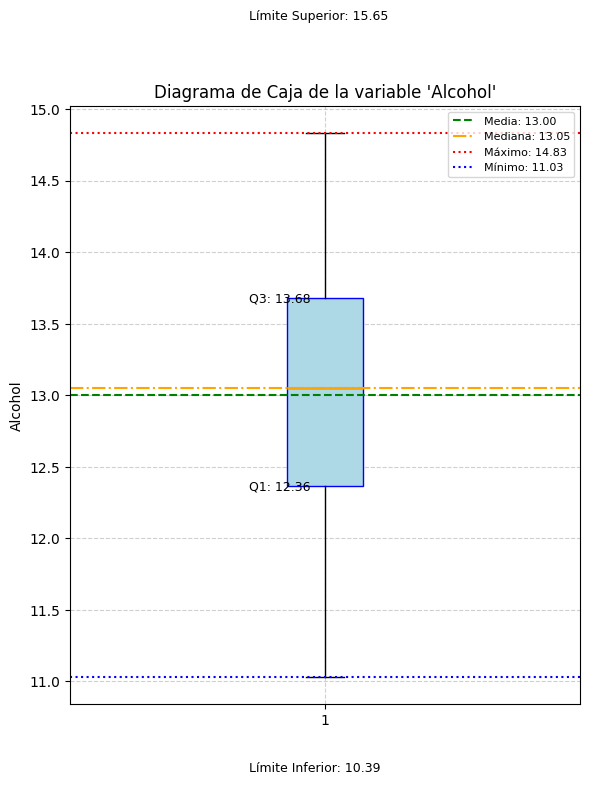

{'Q1': np.float64(12.362499999999999),
 'Q3': np.float64(13.6775),
 'median': np.float64(13.05),
 'mean': np.float64(13.00061797752809),
 'min': np.float64(11.03),
 'max': np.float64(14.83),
 'IQR': np.float64(1.3150000000000013),
 'lim_inf': np.float64(10.389999999999997),
 'lim_sup': np.float64(15.650000000000002)}

In [10]:
def boxplot_variable(df, var):
    """
    Representa un diagrama de caja (boxplot) para una variable numérica y calcula sus principales estadísticas descriptivas.

    Parámetros
    ----------
    df : pandas.DataFrame        #Conjunto de datos.
    var : str                    #Nombre de la columna numérica a analizar.
    Retorna
    -------
    stats : dict                 #Diccionario con las estadísticas calculadas.
    """ 
    # Dibujo del boxplot
    plt.figure(figsize=(6, 8))
    plt.boxplot(df[var].dropna(),
                vert=True,
                patch_artist=True, # permite colorear la caja (por defecto es transparente).
                boxprops=dict(facecolor="lightblue", color="blue"), # color de la caja y su borde.
                medianprops=dict(color="orange", linewidth=2)) # color y grosor de la línea de la mediana
    
    plt.title(f"Diagrama de Caja de la variable '{var}'")
    plt.ylabel(var)

    # Cálculo de estadísticas
    stats = {}
    stats['Q1'] = df[var].quantile(0.25)
    stats['Q3'] = df[var].quantile(0.75)
    stats['median'] = df[var].median()
    stats['mean'] = df[var].mean()
    stats['min'] = df[var].min()
    stats['max'] = df[var].max()
    stats['IQR'] = stats['Q3'] - stats['Q1']
    stats['lim_inf'] = stats['Q1'] - 1.5 * stats['IQR']
    stats['lim_sup'] = stats['Q3'] + 1.5 * stats['IQR']

    # Líneas horizontales para los principales valores
    lineas = {
        'Media': ('mean', 'green', '--'),
        'Mediana': ('median', 'orange', '-.'),
        'Máximo': ('max', 'red', ':'),
        'Mínimo': ('min', 'blue', ':')
    }

    for etiqueta, (clave, color, estilo) in lineas.items():
        plt.axhline(y=stats[clave], color=color, linestyle=estilo,
                    label=f"{etiqueta}: {stats[clave]:.2f}")

    # Textos con valores de cuartiles y límites
    textos = {
        'Q1': stats['Q1'],
        'Q3': stats['Q3'],
        'Límite Inferior': stats['lim_inf'],
        'Límite Superior': stats['lim_sup']
    }

    for etiqueta, valor in textos.items():
        plt.text(0.85, valor, f"{etiqueta}: {valor:.2f}",
                 color='black', fontsize=9, va='center')

    # Ajustes finales
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Retornar diccionario con estadísticas (opcional)
    return stats

boxplot_variable(df, 'Alcohol')


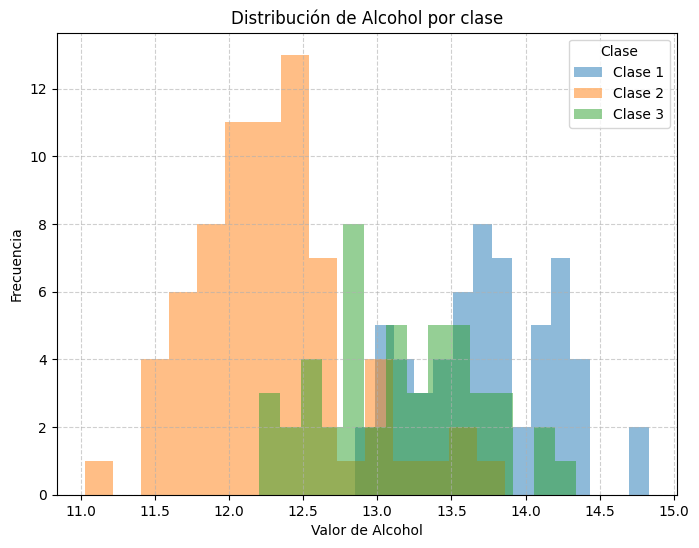

In [11]:
#
# 9. Gráficos y análisis de distribución de variables por clase. Histogramas.
# a. Construye una función que, dado un dataframe, una cadena con el nombre de una variable predictora y una cadena con la variable objetivo
#    muestre el histograma de la variable predictora para cada valor de clase.

def histograma_clase(df, variable, target='class'):
    
    plt.figure(figsize=(8, 6))   # tamañao de la figura. Por defecto son (6 pulg x 6 pulg)
    clases = df[target].unique() # lista valores únicos de la variable a predecir

    # Recorre todas las clases; i es el índice (0, 1, 2, …) y c es el valor de la clase (por ejemplo, 0 o 1).
    for i, c in enumerate(clases): # i índice de la lista clases. c valores de la lista 
        # Filtra el DataFrame df para quedarse solo con las filas de la clase c y selecciona 'plas'
        mascara = df[target] == c # en cada iteración, asigna 'True' a las filas que satisfacen que 'class' == c. 'False' en caso  contrario
        x = df[mascara][variable] # para las filas anteriores, obtenemos el valor de 'variable'

        # dibujamos el histograma de la variable x
        plt.hist(x,                     # variable de la que queremos representar el histograma
                 bins=15,               # número de columnas del histograma
                 alpha=0.5,             # valor de transparencia-opacidad (1: no transparente. 0: invisible)
                 label=f'Clase {c}'     # etiqueta de clase
                )

    plt.title(f'Distribución de {variable} por clase')
    plt.xlabel(f'Valor de {variable}')
    plt.ylabel('Frecuencia')
    plt.legend(title='Clase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


histograma_clase(df, 'Alcohol')

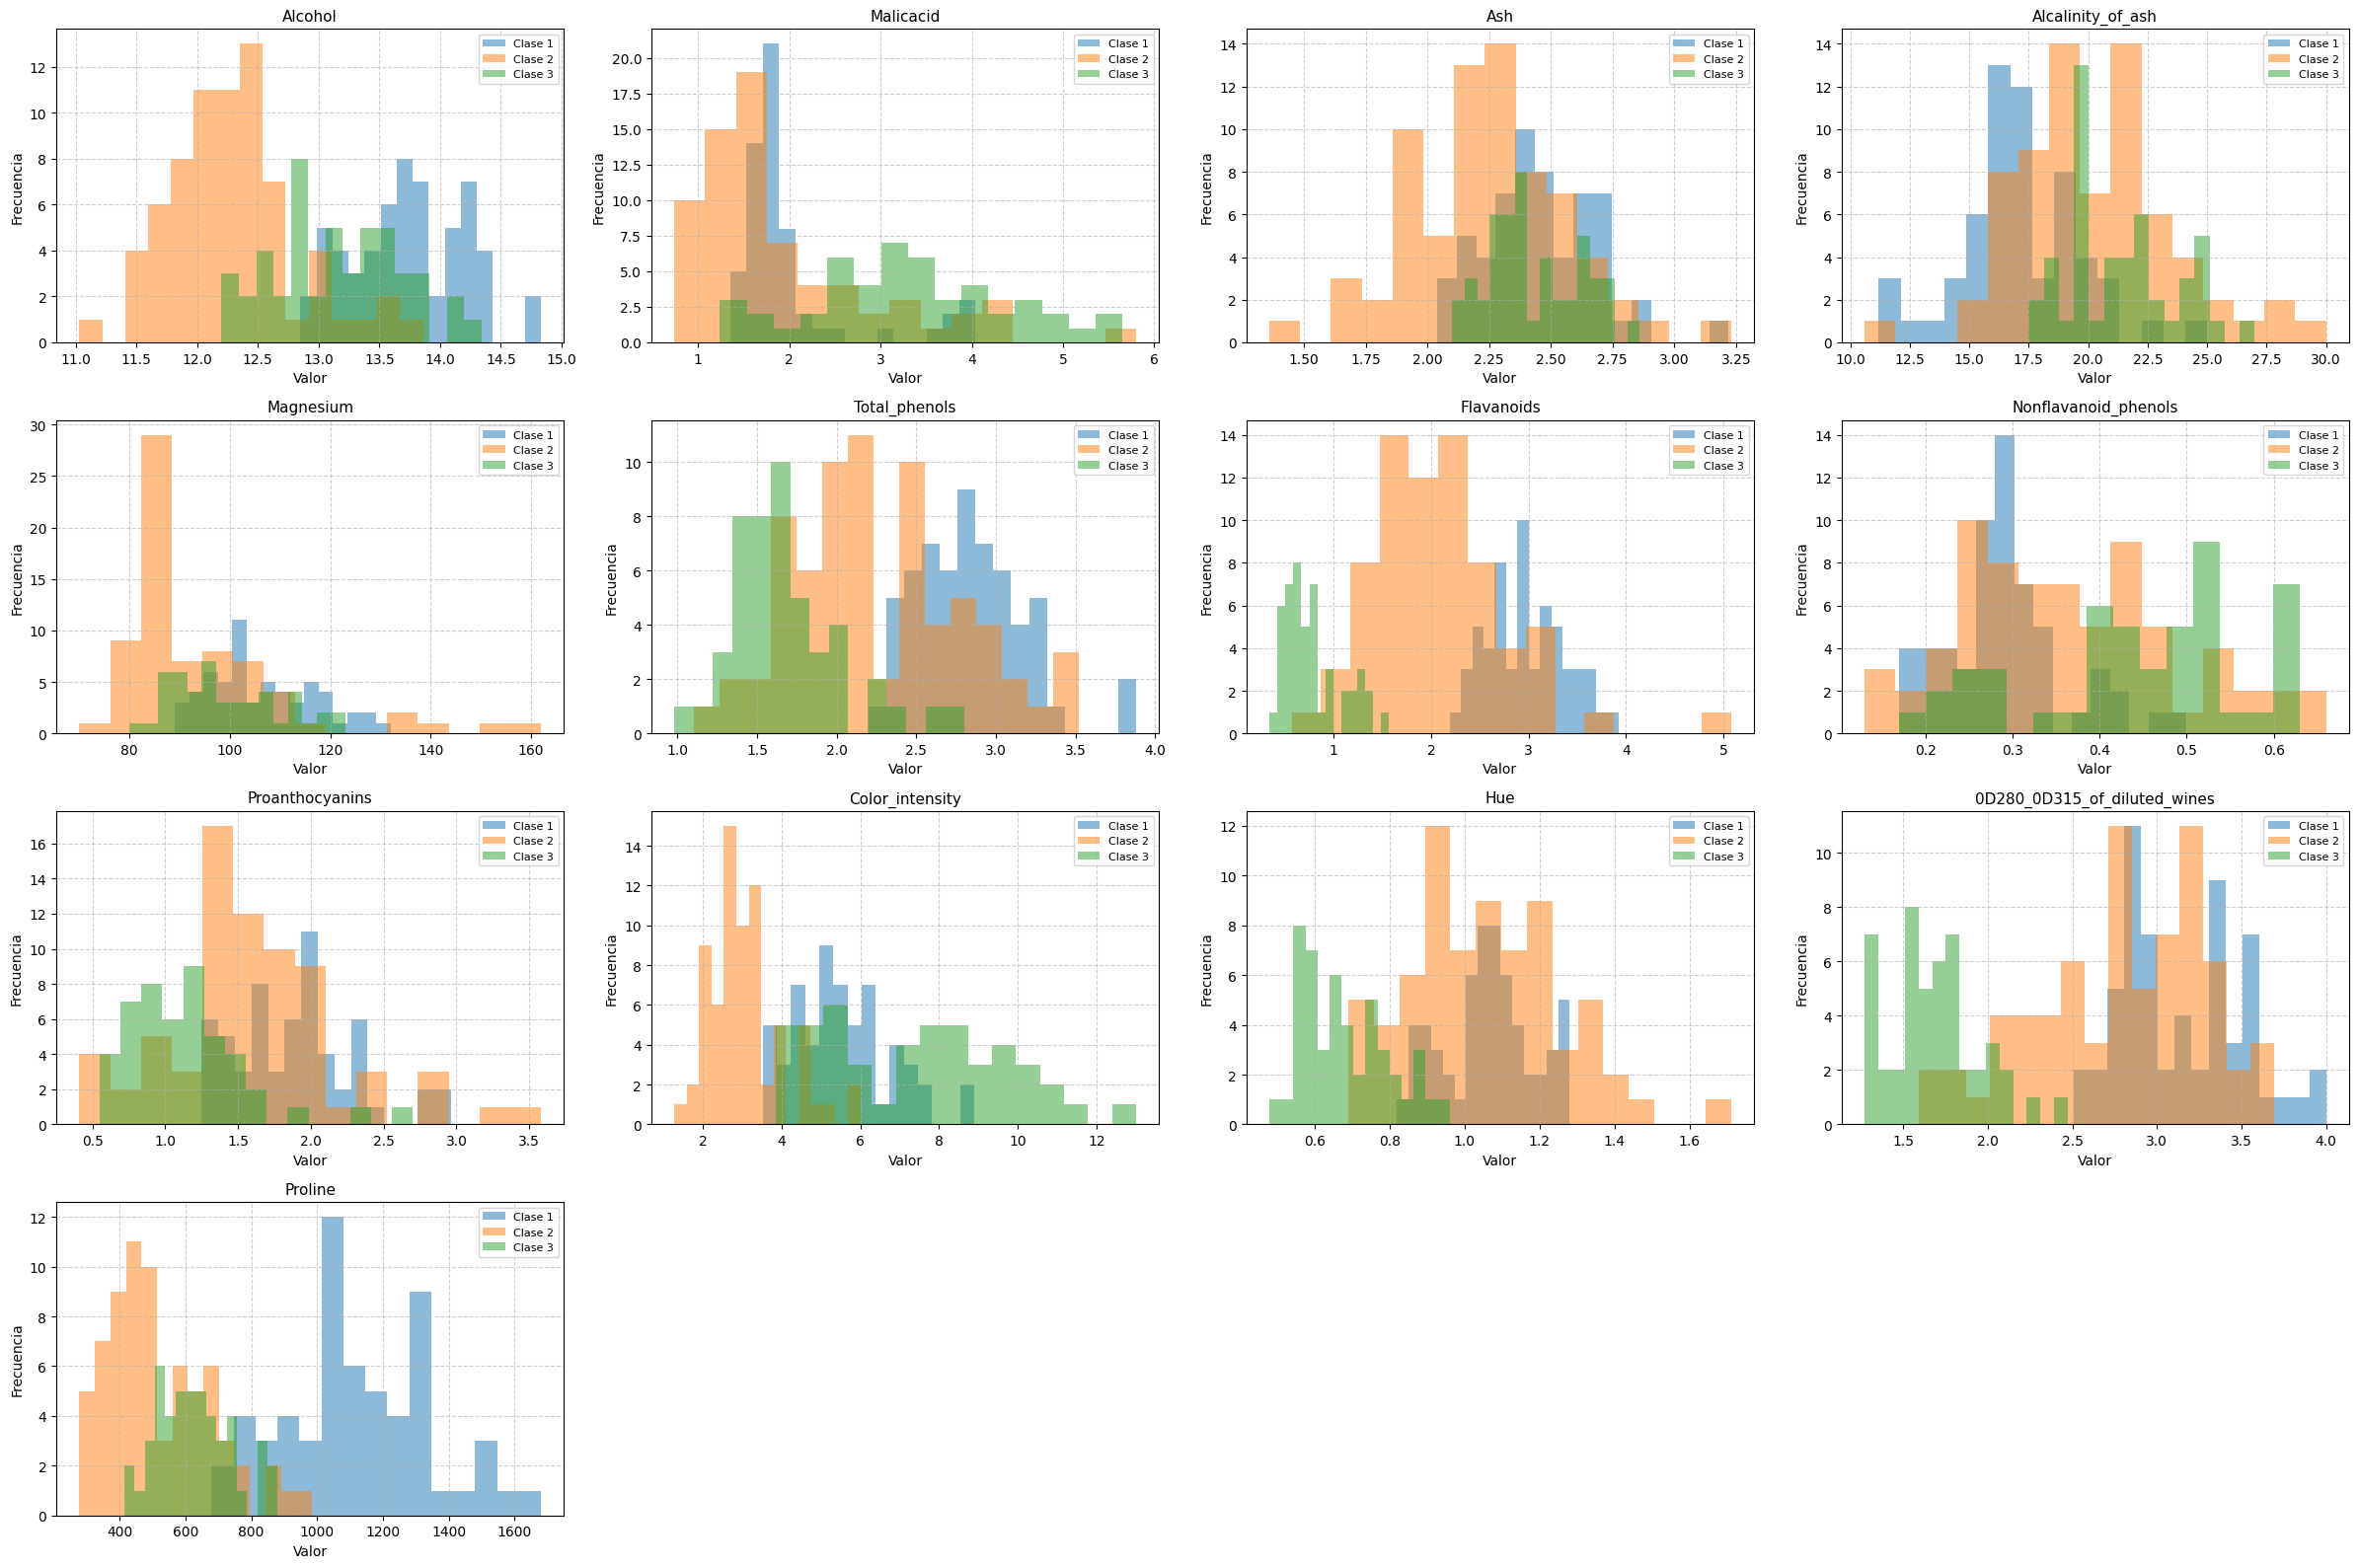

In [12]:
import matplotlib.pyplot as plt
import math

def histogramas_clase(df, variables, target='class'):
    """
    Crea una rejilla de histogramas para comparar la distribución de varias variables
    según las clases del target (por ejemplo, benigno/maligno).
    """

    # Número total de variables a graficar
    n_vars = len(variables)

    # Calcular automáticamente el número de columnas (aprox. raíz cuadrada)
    columnas = math.ceil(math.sqrt(n_vars))

    # Calcular el número de filas necesarias
    filas = math.ceil(n_vars / columnas)

    # Crear la figura y la rejilla de ejes (subplots)
    fig, axes = plt.subplots(filas, columnas, figsize=(6*columnas, 4*filas))

    # Aplanar la matriz de ejes (para recorrerla con un solo índice)
    axes = axes.flatten()

    # Obtener las clases únicas del target (por ejemplo, 0 y 1)
    clases = df[target].unique()

    # Recorrer cada variable a graficar
    for i, variable in enumerate(variables):
        ax = axes[i]  # Seleccionar el eje correspondiente

        # Dibujar un histograma para cada clase
        for c in clases:
            # Filtrar el dataframe por clase y seleccionar la variable actual
            mascara = df[target] == c # en cada iteración, asigna 'True' a las filas que satisfacen que 'class' == c. 'False' en caso  contrario
            x = df[mascara][variable]
            # Dibujar histograma de la variable x de esa clase
            ax.hist(x, bins=15, alpha=0.5, label=f'Clase {c}')

        # Personalizar el gráfico individual
        ax.set_title(f'{variable}', fontsize=11)
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frecuencia')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.6)

    # Apagar los ejes vacíos si sobran
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    # Ajustar márgenes y espacio entre gráficos
    plt.tight_layout()

    # Mostrar toda la figura
    plt.show()

histogramas_clase(df, predictoras)
# Con base a las gráficas siguientes, ¿qué conclusiones puedes extraer?



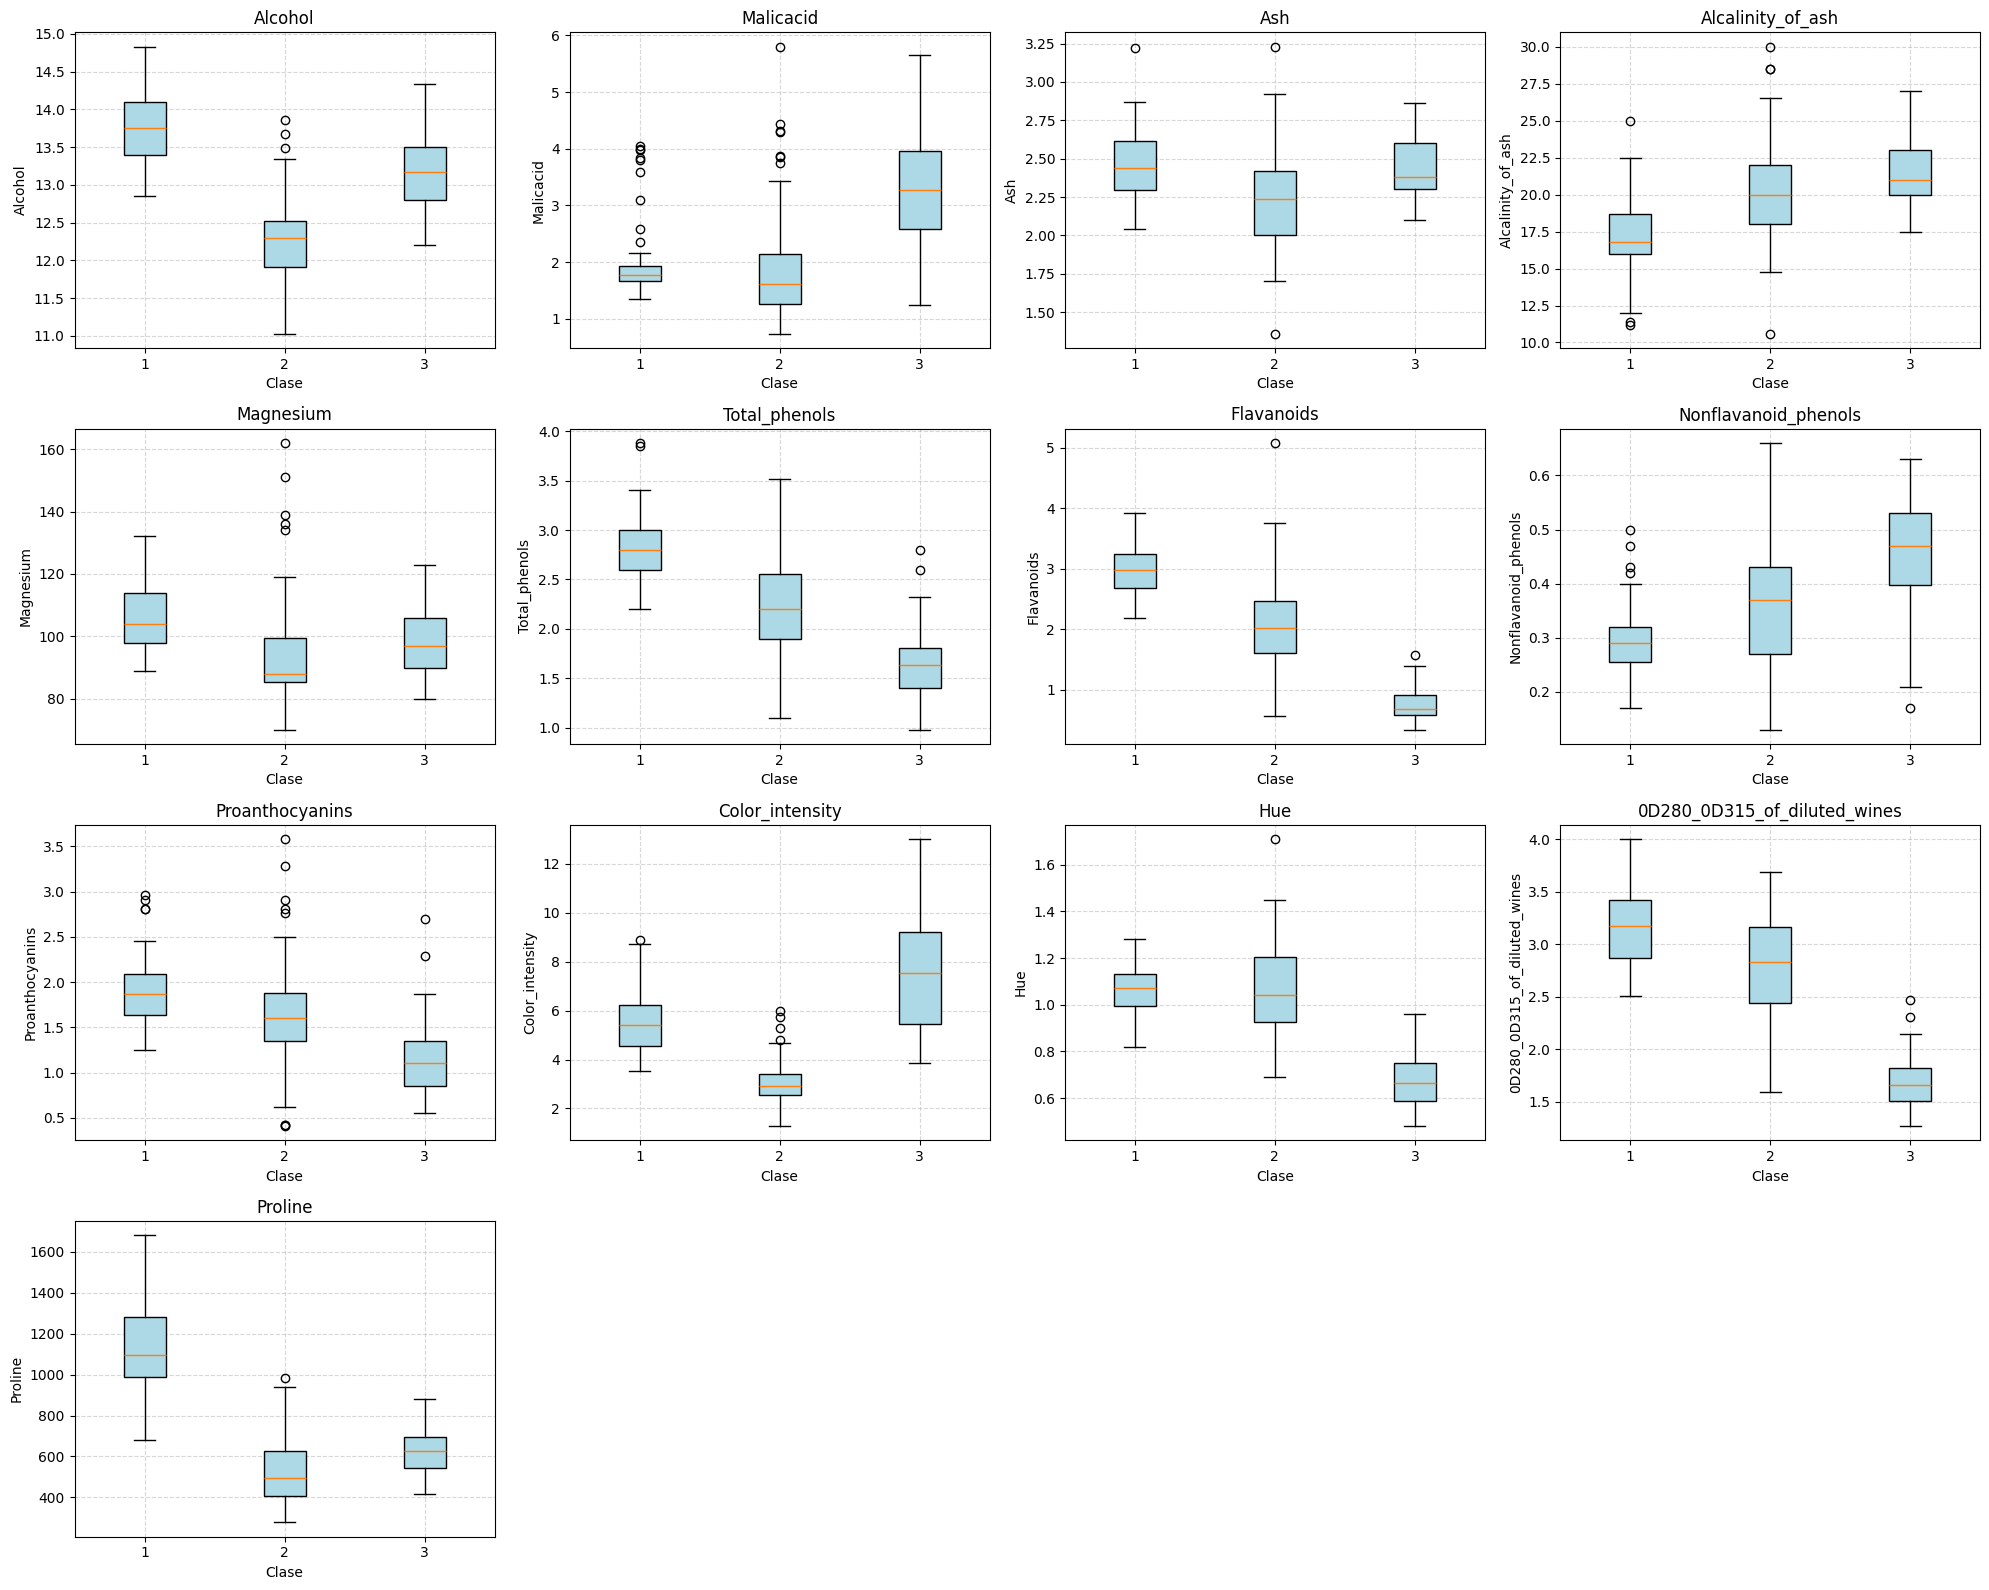

In [13]:
import matplotlib.pyplot as plt
import math

def boxplots_clase(df, variables, target='class'):
    """
    Dibuja, en una rejilla de subplots, boxplots de varias variables numéricas diferenciadas por clase (columna 'target').
    
    Parámetros
    ----------
    df : pandas.DataFrame        #DataFrame con los datos.
    variables : list             #Lista de nombres de columnas numéricas a representar.
    target : str                 #Nombre de la columna de clase (por defecto 'target').
    """

    clases = df[target].unique()  # valores únicos de clase
    num_variables = len(variables)  # número de variables

    # Calcular número de filas y columnas automáticamente (rejilla casi cuadrada)
    columnas = math.ceil(math.sqrt(num_variables))
    filas = math.ceil(num_variables / columnas)

    # Crear figura y ejes
    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 4*filas))
    axes = axes.flatten()  # lista 1D de ejes, para recorrela con un sólo índice

    for i, variable in enumerate(variables): #i: índice y valor de la lista de variables 
        ax = axes[i]                         # en cada iteración, ax es un conjunto de ejes para dibujar cada variable 

        # Lista de valores de la variable 'variable' para cada clase c en la lista de clases
        x = [df[df[target] == c][variable].dropna() for c in clases]

        # Boxplot por clase
        ax.boxplot(
            x,
            tick_labels=clases,                  # # Etiquetas con el nombre de la clase, en el eje X
            patch_artist=True,                   # Rellenar las cajas
            boxprops=dict(facecolor='lightblue') # Color de las cajas
        )

        ax.set_title(variable)
        ax.set_xlabel('Clase')
        ax.set_ylabel(variable)
        ax.grid(True, linestyle='--', alpha=0.5)

    # Apagar ejes sobrantes (si la rejilla de tamaño columasxfilas es más grande que el nº de variables 'num_variables')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


 

boxplots_clase(df, predictoras)


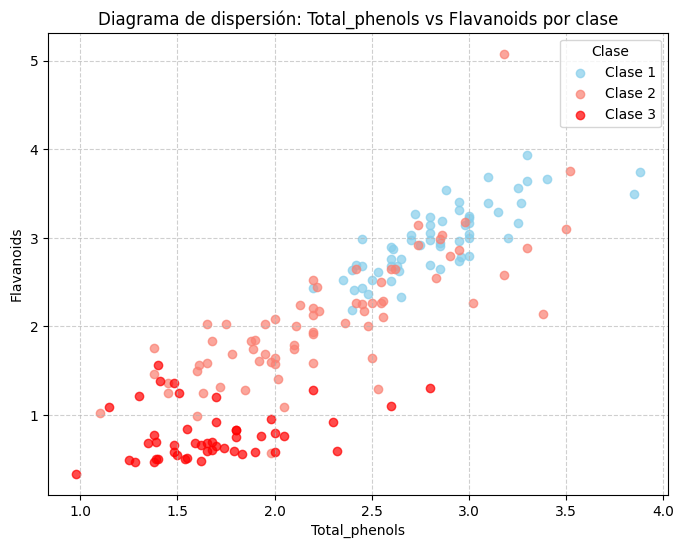

In [14]:
#
# Gráficos y análisis de distribución de variables por clase. Scatter.
# a. Construye una función que, dado un dataframe, dos cadenas con dos nombres de dos variables predictoras y una cadena con la variable objetivo
#    muestre el scatter de las dos variables predictoras discriminadas por clase para cada valor de clase.

import matplotlib.pyplot as plt

def scatter_clase(df, variable1, variable2, target='class'):
    plt.figure(figsize=(8, 6))
    
    # Clase 1
    plt.scatter(df[df[target] == 1][variable1], # una serie -columna de datos con índice- de valores columna 'variable1' de df
            df[df[target] == 1][variable2],     # una serie -columna de datos con índice- de valores columna 'variable2' de df
            color='skyblue',
            alpha=0.7,
            label='Clase 1')

    # Clase 2
    plt.scatter(df[df[target] == 2][variable1],
            df[df[target] == 2][variable2],
            color='salmon',
            alpha=0.7,
            label='Clase 2')
    
    # Clase 3
    plt.scatter(df[df[target] == 3][variable1],
            df[df[target] == 3][variable2],
            color='red',
            alpha=0.7,
            label='Clase 3')

    plt.title(f'Diagrama de dispersión: {variable1} vs {variable2} por clase')
    plt.xlabel(f'{variable1}')
    plt.ylabel(f'{variable2}')
    plt.legend(title='Clase')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

scatter_clase(df, 'Total_phenols', 'Flavanoids')




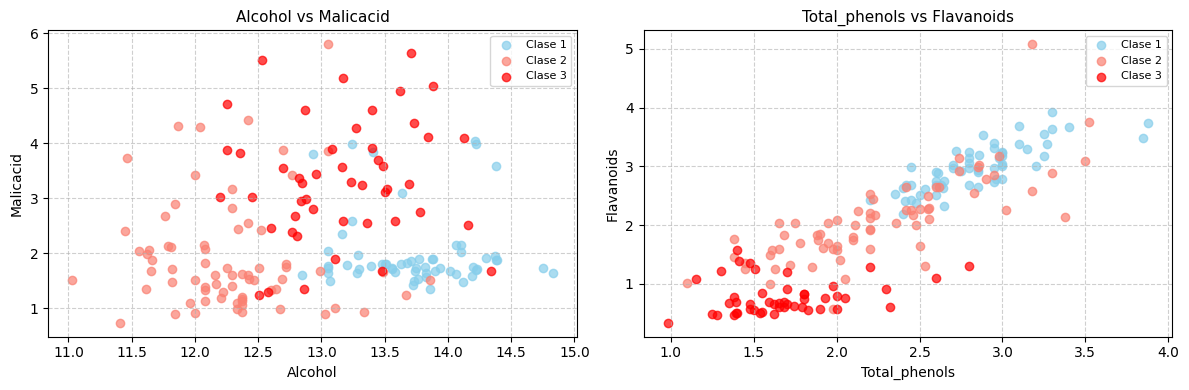

In [15]:
# b. Utilizando esta función, muestra  -mediante un bucle for- todos los scatters por clase, correspondientes a las variables predictoras.

import matplotlib.pyplot as plt
import math

pares = [('Alcohol', 'Malicacid'), ('Total_phenols', 'Flavanoids')]

def scatter_clases(df, pares, target='class'):
    """
    Dibuja varios diagramas de dispersión (scatter plots) por clase para diferentes pares de variables, organizados automáticamente
    en una rejilla de subplots.
    
    Parámetros
    ----------
    df : pandas.DataFrame   #Conjunto de datos.
    pares : list of tuple   #Lista de tuplas con pares de variables
    target : str            #Nombre de la columna de clase (por defecto 'class').
    """

    n_pares = len(pares)  # Número total de gráficos a dibujar

    # Calcular el número de columnas (aprox. cuadrado)
    columnas = math.ceil(math.sqrt(n_pares))

    # Calcular el número de filas necesarias
    filas = math.ceil(n_pares / columnas)

    # Crear la figura y la rejilla de ejes (subplots)
    fig, axes = plt.subplots(filas, columnas, figsize=(6*columnas, 4*filas))

    # Convertir axes en lista 1D para iterar fácilmente sobre ellos
    axes = axes.flatten()

    # Recorrer los pares de variables
    for i, (var1, var2) in enumerate(pares):
        ax = axes[i]  # seleccionar el eje correspondiente

        # Dibujar los puntos de la clase 1 (malignos)
        ax.scatter(df[df[target] == 1][var1],
                   df[df[target] == 1][var2],
                   color='skyblue', alpha=0.7, label='Clase 1')

        # Dibujar los puntos de la clase 2 (benignos)
        ax.scatter(df[df[target] == 2][var1],
                   df[df[target] == 2][var2],
                   color='salmon', alpha=0.7, label='Clase 2')

        # Dibujar los puntos de la clase 3 (benignos)
        ax.scatter(df[df[target] == 3][var1],
                   df[df[target] == 3][var2],
                   color='red', alpha=0.7, label='Clase 3')


        # Personalización del gráfico individual
        ax.set_title(f'{var1} vs {var2}', fontsize=11)
        ax.set_xlabel(var1)
        ax.set_ylabel(var2)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize=8)

    # Apagar ejes sobrantes si hay más espacios que gráficos
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    # Ajustar márgenes y mostrar
    plt.tight_layout()
    plt.show()

scatter_clases(df, pares)


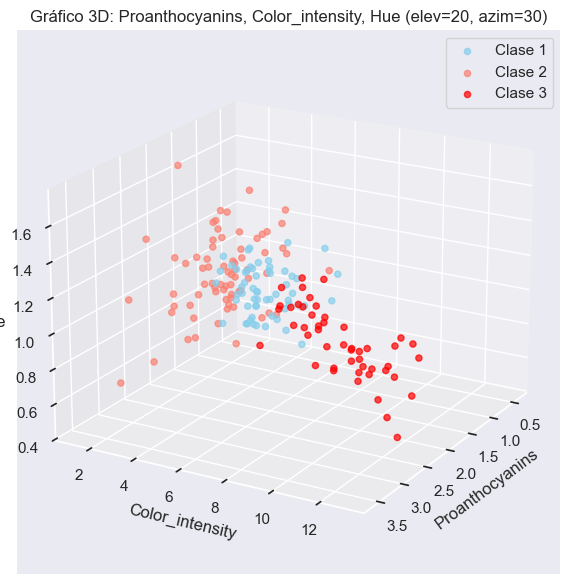

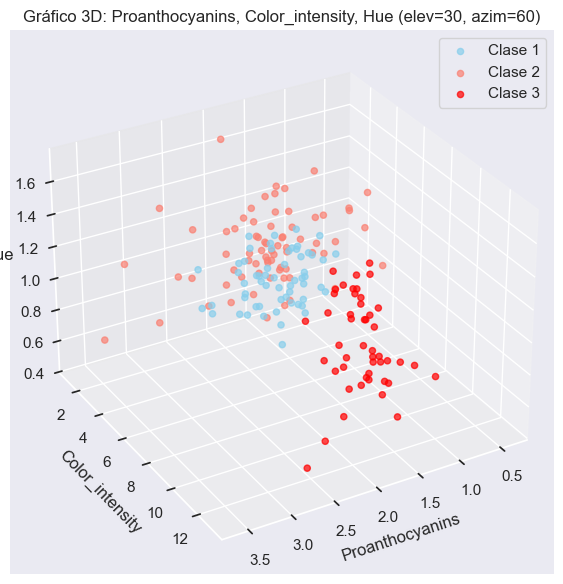

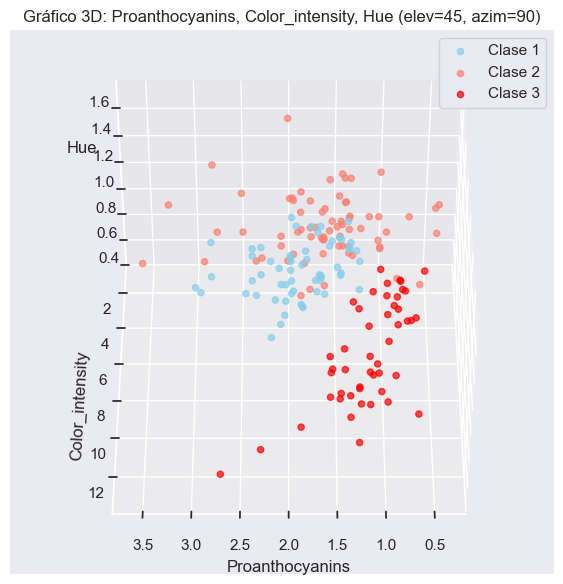

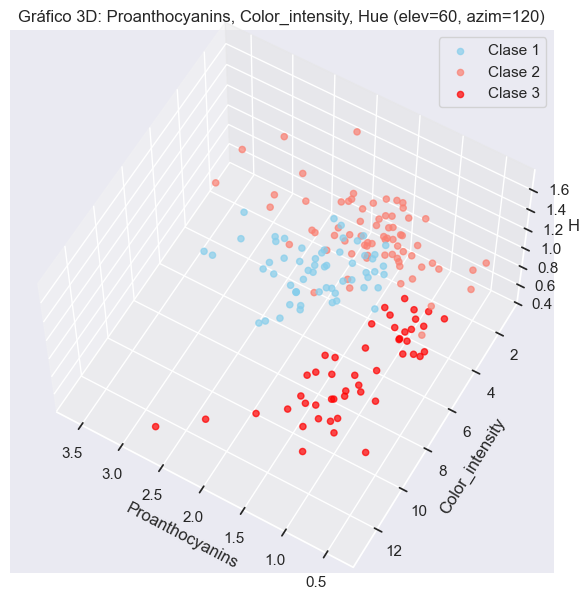

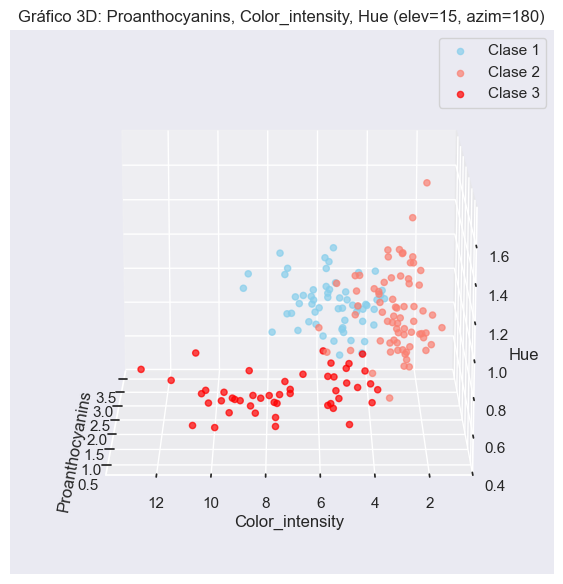

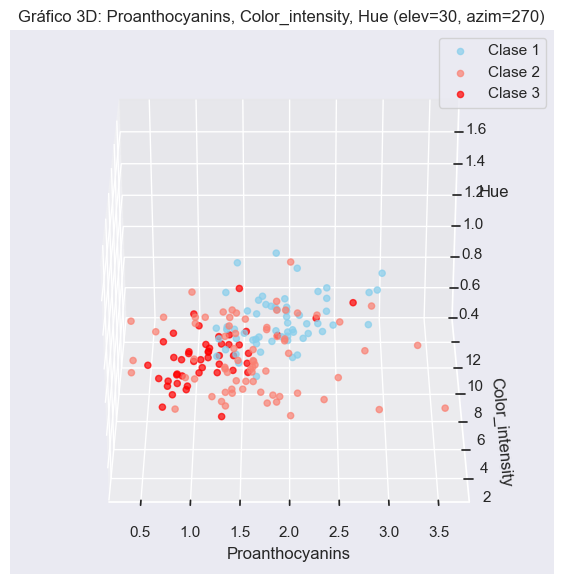

In [58]:
#
#  Gráfico 3D
# a. Elige tres variables predictoras originales, represéntalas desde diferentes ángulos (5 combinaciones de azimut y altura).
# Haz esta representación mediante el uso iterativo de una función que acepte un dataframe, tres cadenas de caracteres
# cada una de las cuales contenga el nombre de una variable predictora, un valor de azimut y un valor de altura.
# b. En base a la visualización anterior, extrae las conclusiones pertinentes.


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def grafico_3d(df, x_var, y_var, z_var, elev, azim):
    """
    Dibuja un gráfico 3D de tres variables numéricas con una orientación definida.
    Parámetros:
    df    : DataFrame con los datos
    x_var : nombre de la variable para el eje X
    y_var : nombre de la variable para el eje Y
    z_var : nombre de la variable para el eje Z
    elev  : ángulo de elevación de la cámara
    azim  : ángulo de rotación (azimut)
    """
    plt.figure(figsize=(8, 6))
    ax = plt.axes(projection='3d')
    plt.title(f'Gráfico 3D: {x_var}, {y_var}, {z_var} (elev={elev}, azim={azim})')
    # Clase 1
    x0 = df[df['class'] == 1][x_var]
    y0 = df[df['class'] == 1][y_var]
    z0 = df[df['class'] == 1][z_var]
    ax.scatter3D(x0, y0, z0, color='skyblue', alpha=0.7, label='Clase 1')
    # Clase 2
    x1 = df[df['class'] == 2][x_var]
    y1 = df[df['class'] == 2][y_var]
    z1 = df[df['class'] == 2][z_var]
    ax.scatter3D(x1, y1, z1, color='salmon', alpha=0.7, label='Clase 2')
    # Clase 3
    x1 = df[df['class'] == 3][x_var]
    y1 = df[df['class'] == 3][y_var]
    z1 = df[df['class'] == 3][z_var]
    ax.scatter3D(x1, y1, z1, color='red', alpha=0.7, label='Clase 3')

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_zlabel(z_var)
    ax.legend()
    # Cambiar orientación
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


var1, var2 , var3 = ('Proanthocyanins', 'Color_intensity', 'Hue')


# Gráfico 1
grafico_3d(df, var1, var2, var3, elev=20, azim=30)

# Gráfico 2
grafico_3d(df, var1, var2, var3, elev=30, azim=60)

# Gráfico 3
grafico_3d(df, var1, var2, var3 , elev=45, azim=90)

# Gráfico 4
grafico_3d(df,  var1, var2, var3 ,elev=60, azim=120)

# Gráfico 5
grafico_3d(df, var1, var2, var3, elev=15, azim=180)

# Gráfico 6
grafico_3d(df, var1, var2, var3, elev=30, azim=270)



In [59]:
# estandarizamos las variables predictoras. Recordamos que están en el objeto X, un dataframe de Pandas.
# la estandarización se realiza para que todas las variables estén en una escala comparable y el algoritmo las tenga en cuenta a todas.

from sklearn.preprocessing import StandardScaler # importamos las librerías necesarias

scaler = StandardScaler() # instanciamos un objeto StandardScaler()
X_scaled = scaler.fit_transform(X) # entrenamiento y transformación de las variables del dataframe X a variables con media 0 y desv. típica 1 



In [60]:
# Verificamos que la estandarización se ha llevado a cabo exitosamente.
# Nota X_scaled es un array de numpy -no es un dataframe de Pandas
print(type(X_scaled))
X_scaled

<class 'numpy.ndarray'>


array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [61]:
from sklearn.cluster import KMeans
# Importa la clase KMeans de scikit-learn, que implementa el algoritmo K-means

km = KMeans(
    n_clusters=3,      # Número de clusters (K). El algoritmo intentará agrupar los datos en 3 grupos distintos.

    init='k-means++',  # Inicialización centroides. 'k-means++' elige centroides iniciales de forma  que celera convergencia y mejora resultados.

    n_init='auto',     # Número de veces que el algoritmo se ejecuta con distintas inicializaciones de centroides.
                       # Se conserva el resultado con la menor suma de distancias internas (inercia). Es decir, el algoritmo se lanza n_init veces
                       # cada vez con centroides iniciales diferentes, se queda con la mejor ejecución: la que tenga menor inercia (inertia_)

    max_iter=300,      # Número máximo de iteraciones permitidas en cada ejecución. Evita bucles infinitos si el algoritmo no converge rápidamente.

    tol=0.0001,        # Tolerancia. Si el cambio en la posición de los centroides entre iteraciones es menor que este valor, el algoritmo se detiene.

    random_state=10,   # Semilla del generador de números aleatorios. Garantiza que los resultados sean reproducibles.

    algorithm='elkan'  # Algoritmo interno usado para calcular K-means. Acelera el cálculo de distancias y la asignación de puntos a centroides.
    
)


In [62]:
# km.fit(X_scaled)

# 1. Inicializa 𝑘 centroides (aleatoriamente o con k-means++)
# 2. Repite hasta converger:
#      asigna cada punto al centroide más cercano
#      recalcula los centroides como la media de los puntos asignados
# 3. Guarda el resultado dentro del objeto km

km.fit(X_scaled)

#Después del fit, el modelo ya tiene la siguiente información:
    # km.cluster_centers_ : coordenadas de los centroides
    # km.labels_          : etiqueta (cluster) asignada a cada punto
    # km.inertia_         : suma de distancias internas (medida de cuán compacto es cada clúster)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,10
,copy_x,True
,algorithm,'elkan'


In [63]:
#-------------------------------------------------------------------------#
#                      Información sobre los clústeres                    #
#-------------------------------------------------------------------------#
# Hallar el número de clústeres: 
# Hallar el número coordenadas de cada centro de un clúster:
# hallar las coordenadas de los centroides de los clusters:
# hallar el número de iteraciones necesarias para la convergencia del algoritmo k-means

In [64]:
print(f'Número de clústeres: {km.cluster_centers_.shape[0]}')
print(f'\nNúmero coordenadas de cada centro de un clúster: {km.cluster_centers_.shape[1]}')
print(f'\nCoordenadas de los centroides de los clusters: {km.cluster_centers_}')
print(f'\nNúmero de iteraciones: {km.n_iter_}')

Número de clústeres: 3

Número coordenadas de cada centro de un clúster: 13

Coordenadas de los centroides de los clusters: [[ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]
 [-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]]

Número de iteraciones: 8


In [65]:
# hallar la suma de las distancias cuadradas de cada punto a su centroide más cercano.
print('Inercia (suma de las distencias al cuadrado de cada elemento de un clúster a su centroide): ',km.inertia_)

Inercia (suma de las distencias al cuadrado de cada elemento de un clúster a su centroide):  1277.928488844642


In [66]:
# hallar las etiquetas asignadas por k-means a las instancias (ejemplos.líneas del dataset)  
print(f'Etiquetas de clúster asignadas por k-means a cada instancia de X_scaled:\n {km.labels_}')

Etiquetas de clúster asignadas por k-means a cada instancia de X_scaled:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 0 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 0 2 2 1 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [67]:
# hallar el número de etiquetas totales asignadas por k-means
len(km.labels_)

178

In [68]:
# Coordenadas del centroide 0. Este centroide es el centrode de los puntos del conjuntos con etiqueta 0
centroide_0 = km.cluster_centers_[0]
print(centroide_0)

[ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
 -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
 -0.40708796]


In [69]:
# Puntos del dataset que tienen la etiqueta 0 asignada por k-means
cluster0_puntos = X_scaled[km.labels_ == 0]
print(cluster0_puntos)

[[-4.45458753e-01 -8.76431899e-01 -1.26663723e+00 -8.09251184e-01
   1.81450206e-02 -4.40821213e-01 -6.21726134e-01  1.35488840e+00
  -1.70109651e+00  2.99299548e-01  9.89369528e-02 -1.44307219e+00
  -9.45454722e-01]
 [ 6.09998823e-02  1.36772596e+00 -1.70034959e-01  9.02373272e-01
  -1.03505509e+00 -1.03368389e+00 -4.41012124e-01  1.99951289e+00
   5.09876168e-02 -1.11641936e-01 -5.15290467e-01 -8.49846211e-01
  -7.38462629e-01]
 [-2.84874308e-01  9.81730812e-01 -1.41285087e+00 -1.04947918e+00
  -1.38612179e+00 -1.06573052e+00 -7.82360809e-01  5.49107795e-01
  -1.33315885e+00 -7.17239912e-01 -1.12951789e+00 -6.94477501e-01
  -1.19384523e+00]
 [-1.73700461e-01 -8.85408531e-01 -1.70034959e-01 -4.48909194e-01
   1.56283851e+00 -1.25801030e+00 -7.82360809e-01 -1.22360954e+00
  -1.14042959e+00 -4.14440924e-01 -8.66277565e-01 -1.86680504e+00
  -3.72245850e-01]
 [-1.48995162e-01  5.86759028e-01  1.22392314e-01  1.51660791e-01
   2.98998383e-01 -1.59449993e+00 -8.12479811e-01 -9.81875357e-01


## Inercia en K-means

$$
\displaystyle
\text{Inercia} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \left\| x_i - \mu_k \right\|^2
$$

Donde:

- $K$: número de clusters  
- $C_k$: conjunto de puntos del cluster $k$  
- $\mu_k$: centroide del cluster $k$



In [70]:
inercias = [] # lista vacía dónde iremos colocando valores de inercia
n_clusters = range(1,11) # evaluaremos la inercia para 1 clúster, 2 clústeres, 3 clústeres,...., 10 clústeres
for n in n_clusters:
    print(f'Evaluando {n} clústeres')
    km = KMeans(n_clusters=n,  # instancia mos un objeto k-means para n clústeres
           init='k-means++',   # método de asignación de centroides. Pueden asignarse aleatoriamente por este método 'k-means++'
           n_init='auto',      # Número de veces que el algoritmo se ejecuta con distintas inicializaciones de centroides.
           max_iter=300,       # Número máximo de iteraciones en cada ejecución. Evita bucles infinitos si el algoritmo no converge rápidamente.
           tol=0.0001,         # Cambio en la posición de los centroides entre iteraciones es menor que este valor, el algoritmo se detiene.
           random_state=10,    # reproductibilidad
           algorithm='lloyd'   # algoritmo cálculo de distancias y la asignación de puntos a centroides.
           )
    km.fit(X_scaled)           # Entrenamiento del algoritmo
    inercias.append(km.inertia_)  #lista que contiene la inercia calculada para cada n

Evaluando 1 clústeres
Evaluando 2 clústeres
Evaluando 3 clústeres
Evaluando 4 clústeres
Evaluando 5 clústeres
Evaluando 6 clústeres
Evaluando 7 clústeres
Evaluando 8 clústeres
Evaluando 9 clústeres
Evaluando 10 clústeres


In [71]:
inercias

[2314.0,
 1659.0079672511501,
 1277.928488844642,
 1228.1535319352024,
 1148.4945291758181,
 1092.7284063103193,
 1025.2461645226902,
 1008.0606770691077,
 916.6324965112908,
 883.8220444573618]

## Método del codo (*Elbow Method*)

El método del codo se utiliza para elegir un valor adecuado del número de clusters **$K$** en K-means.

A medida que aumentamos $K$, la **inercia siempre disminuye**, porque cada cluster tiene menos puntos y los centroides se ajustan mejor. Sin embargo, llega un punto donde **agregar más clusters produce mejoras cada vez menores**.

Ese punto de cambio en la pendiente (donde la curva pasa de bajar mucho a bajar poco) se llama **"codo"**, y suele tomarse como un buen valor para $K$.


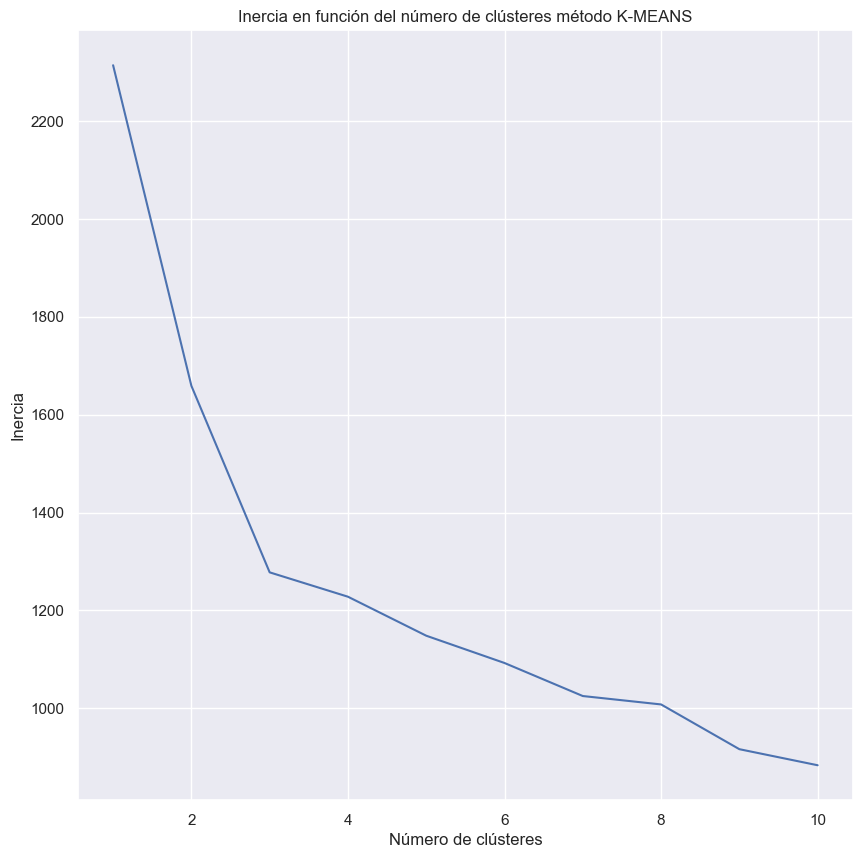

In [72]:
plt.figure(figsize=(10,10))
plt.plot(n_clusters, inercias)
plt.title('Inercia en función del número de clústeres método K-MEANS')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.show()

## Coeficiente de la Silueta.

Para cada punto correspondiente a una instancia de los atributos de entrada, podemos definir el coeficiente de la silueta como:



a (cohesión) = distancia promedio de cada punto a todos los demás puntos en el mismo cluster.

b (separación) = distancia promedio de cada punto a todos los demás puntos en el cluster más cercano.

Dado esto, se dice que el coeficiente de la silueta (s) para cada punto (instancia) está dado por:

$$
s = \frac{b - a}{\max(a, b)}
$$


donde el valor de s puede variar entre -1 y 1,

### Silhouette global (*Silhouette Score*)

El *silhouette score* del clustering entero es la media de los s (coeficiente de Silhouette) de todos los puntos. Para K-means buscamos el K (número de clústeres) con *silhouette score* más alto



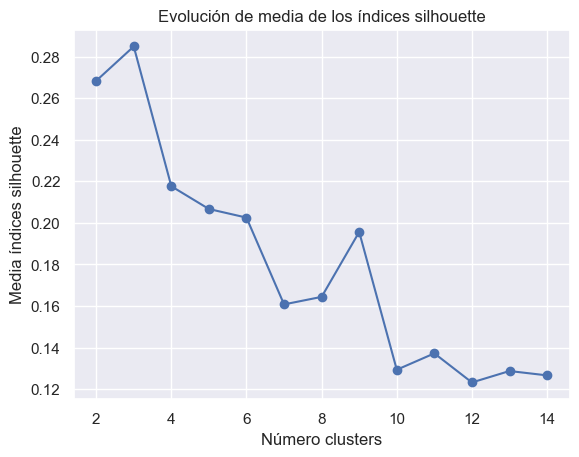

In [73]:
# Método silhouette para identificar el número óptimo de clusters
from sklearn.metrics import silhouette_samples, silhouette_score

num_clusters = range(2, 15)   # rango de número de clústeres que queremos evaluar
valores_medios_silhouette = []    # lista vacía para guardar el valor del coeficiente de Silhouette global de cada n clústeres

for n_clusters in num_clusters:
    km = KMeans(
                        init='k-means++',
                        n_clusters   = n_clusters, 
                        n_init       = 'auto', 
                        max_iter     = 300,
                        tol          = 0.0001,
                        random_state = 10,
                        algorithm    = 'lloyd'
                    )
    cluster_labels = km.fit_predict(X_scaled) # etiquetas de clústeres predichas por k-means
    silhouette_medio = silhouette_score(X_scaled, cluster_labels) # la media del silhouette s de todos los puntos del dataset.
    valores_medios_silhouette.append(silhouette_medio) # añadimos a la lista los valores de s medio (global)
    
fig, ax = plt.subplots() # fig es el lienzo y ax es un conjunto de ejes sobre el lienzo fig. Tamaño por defecto 6x6
ax.plot(num_clusters, valores_medios_silhouette, marker='o') # puntos con segmentos entre ellos
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');


Para 2 clústeres el silhouette_score es 0.26831340971052126 

El tamaño del cluster 0 es: 65

El tamaño del cluster 1 es: 113


Para 3 clústeres el silhouette_score es 0.2848589191898987 

El tamaño del cluster 0 es: 51

El tamaño del cluster 1 es: 62

El tamaño del cluster 2 es: 65


Para 4 clústeres el silhouette_score es 0.21760670611865185 

El tamaño del cluster 0 es: 24

El tamaño del cluster 1 es: 62

El tamaño del cluster 2 es: 60

El tamaño del cluster 3 es: 32


Para 5 clústeres el silhouette_score es 0.20666225560533946 

El tamaño del cluster 0 es: 26

El tamaño del cluster 1 es: 62

El tamaño del cluster 2 es: 49

El tamaño del cluster 3 es: 13

El tamaño del cluster 4 es: 28


Para 6 clústeres el silhouette_score es 0.20252045494762938 

El tamaño del cluster 0 es: 15

El tamaño del cluster 1 es: 60

El tamaño del cluster 2 es: 18

El tamaño del cluster 3 es: 13

El tamaño del cluster 4 es: 27

El tamaño del cluster 5 es: 45


Para 7 clústeres el silhouette_score es 0.16

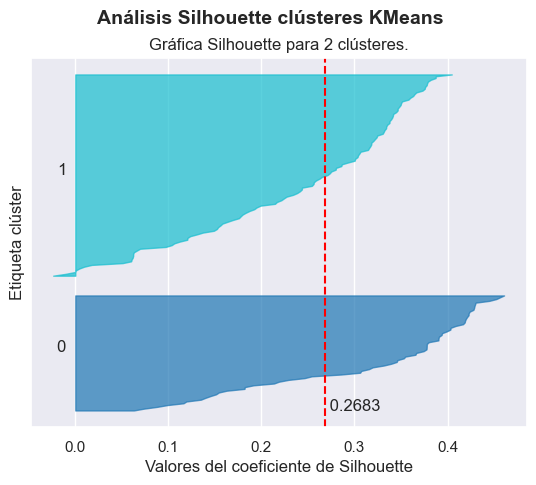

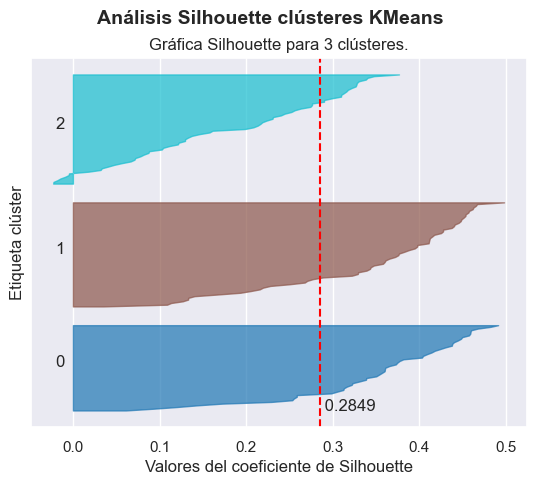

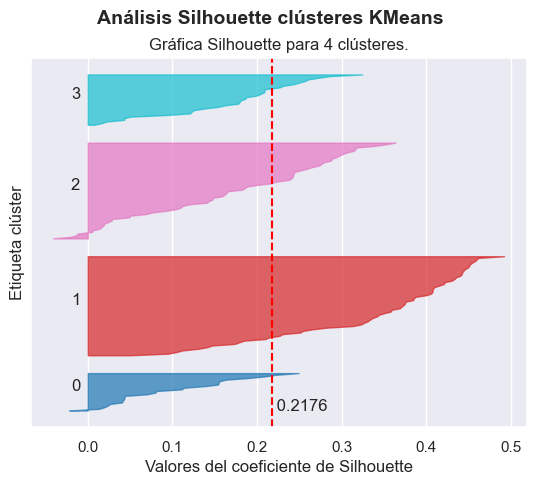

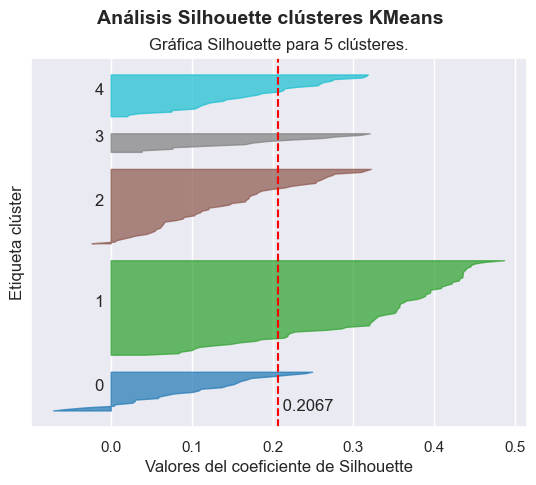

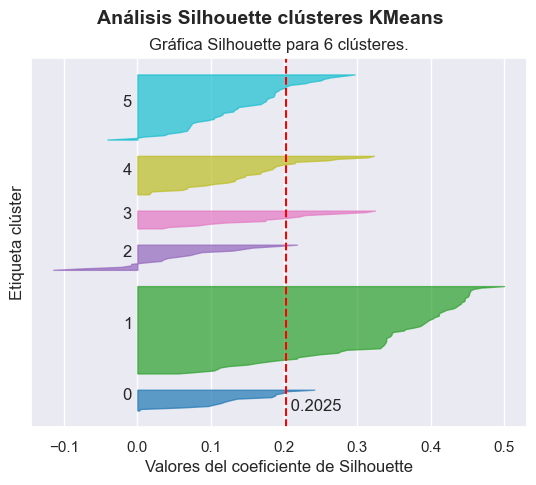

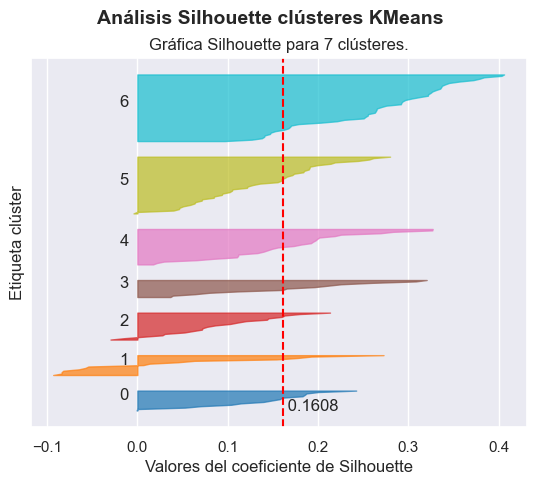

In [74]:
import matplotlib.cm as cm
rango_n_clusteres = [2, 3, 4, 5, 6, 7]

for n_clusteres in rango_n_clusteres: #Para 2,3,4,5 clústeres

    fig, ax = plt.subplots()  # fig es el lienzo de dibujo, donde estrán cada uno de los conj. de ejes ax
    # configuramos el eje Y: yticks son marcas o números del eje Y (0, 1, 2, …).
    # La lista vacía [] significa no muestrar marcas ni números en el eje Y    
    ax.set(yticks = []) 
  
    #cluster = KMeans(n_clusters=n_clusteres, random_state=10, n_init="auto") # instanciamos un objeto Kmeans con n_clusteres
    km = KMeans(n_clusters=n_clusteres, random_state=10, n_init="auto")
    #cluster_labels = cluster.fit_predict(X_scaled)                           #predecimos etiquetas de clúster a cada punto del dataset escalado
    cluster_labels = km.fit_predict(X_scaled)  # etiquetas puntos para un número de n_clusteres
  
      
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)  #coeficiente de silhouette instancias (puntos) del dataset
   
    silhouette_medio = silhouette_score(X_scaled, cluster_labels)  # calculamos la media de los cofecientes silhouette para un número de n_clusteres
    print(
        f"\nPara {n_clusteres} clústeres el silhouette_score es {silhouette_medio} \n"
    )

    #DIBUJAMOS LAS GRÁFICAS DE CLUSTERS-COEFICIENTES DE SILHOUETTE-SILHOUETTE SCORE
    y_inf = 0  #limite interior en el eje y para dibujar el clúster i
    for i in range(n_clusteres):#para cada uno de cada conjunto de clusters (2 clústers, se ejecuta 2 veces con valores 0,1..., etc)
       
        cluster_i_silhouette_values = sample_silhouette_values[cluster_labels == i]#valores coeficiente silhouette para el cluster i

        cluster_i_silhouette_values.sort()#ordenamos los valores de los coeficientes del clúster i

        size_cluster_i = len(cluster_i_silhouette_values) #tamaño del conjunto de puntos del clúster con etiqueta i 

        print(f'El tamaño del cluster {i} es: {size_cluster_i}\n')

        # y_upper = y_lower + número de puntos del clúster i
        y_sup = y_inf + size_cluster_i #limite superior en el eje y para dibujar el clúster i.
        #elegimos un color i del mapa de colores tab10 para cada clúster
        cmap = plt.get_cmap("tab10", n_clusteres)
        color = cmap(i)  # color i-ésimo

        # para cada “fila” en el eje y se dibuja una barra horizontal desde x=0 hasta el valor silhouette.
        # np.arange(y_lower, y_upper) no incluye y_upper, por eso salen justo y_upper - y_lower elementos, que es size_cluster_i.
        ax.fill_betweenx(  # en el conjunto de ejes ax
            np.arange(y_inf, y_sup), # valores del eje y donde se dibuja el bloque. genera size_cluster_i posiciones (una por valor silhouette).
                                         # Ejemplo: si y_lower=40 y y_upper=60, produce: 40, 41, 42, …, 59 (uno por cada punto del cluster)
            0,                           # límite izquierdo en el eje x (arranca desde 0)
            cluster_i_silhouette_values, # límite derecho en el eje x (el valor silhouette de cada punto)
            facecolor=color,             # relleno
            edgecolor=color,             # color borde
            alpha=0.7,                   # transparencia
        )
   
        ax.text(-0.02, y_inf + 0.5 * size_cluster_i, str(i)) # etiqueta de cada clúster
        y_inf = y_sup + 10 # deja un hueco de 10 entre clústeres    

    ax.set_title(f"Gráfica Silhouette para {n_clusteres} clústeres.")
    ax.set_xlabel("Valores del coeficiente de Silhouette")
    ax.set_ylabel("Etiqueta clúster")
    
    # Línea vertical para indicar el valor de coeficiente de Silhoutte del dataset   
    ax.axvline(x=silhouette_medio, color="red", linestyle="--")
    ax.text(silhouette_medio, 0, f' {silhouette_medio:.4f}')  # etiqueta de cada valor de silhoutte medio (para un número n_clústeres) 
    plt.suptitle(
        "Análisis Silhouette clústeres KMeans",
        fontsize=14,
        fontweight="bold"
    )

plt.show()

## AGRUPAMIENTO JERÁRQUICO
### Métodos de medida de distancia entre clústeres

In [75]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

#Matrices de agrupamiento jerárquico para cada método de distancia entre clústeres
linkage_complete = linkage(X_scaled, method="complete", metric="euclidean")
linkage_average = linkage(X_scaled, method="average", metric="euclidean")
linkage_single = linkage(X_scaled, method="single", metric="euclidean")


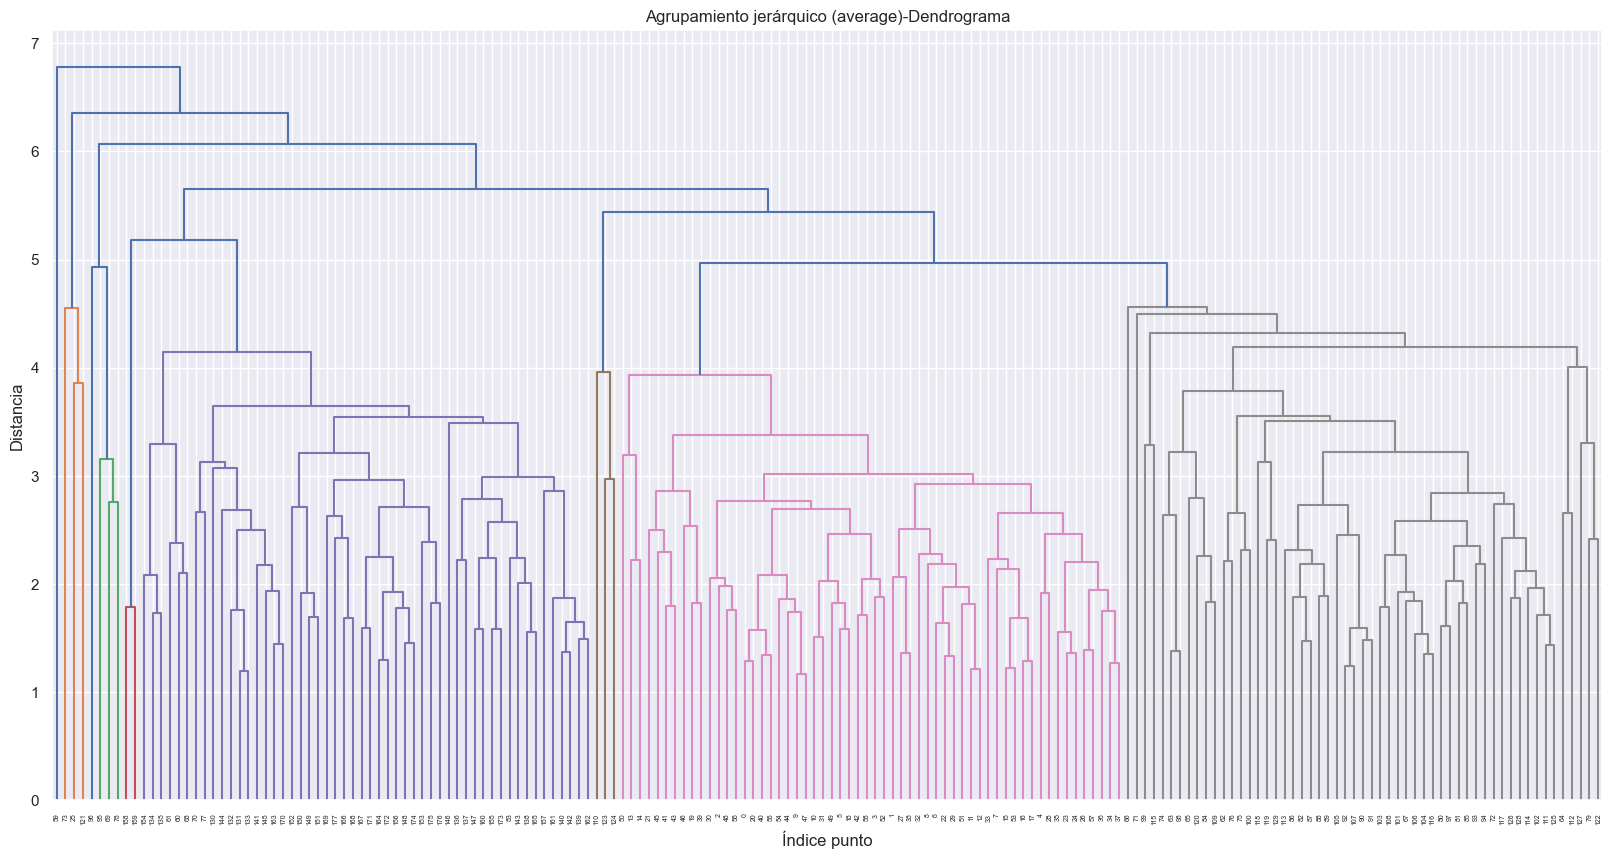

In [76]:
# Dendograma conjunto X_scaled método de medida entre clústeres 'average'
plt.figure(figsize=(20,10))
dendrogram(linkage_average)
plt.title("Agrupamiento jerárquico (average)-Dendrograma")
plt.xlabel("Índice punto")
plt.ylabel("Distancia")
plt.show()

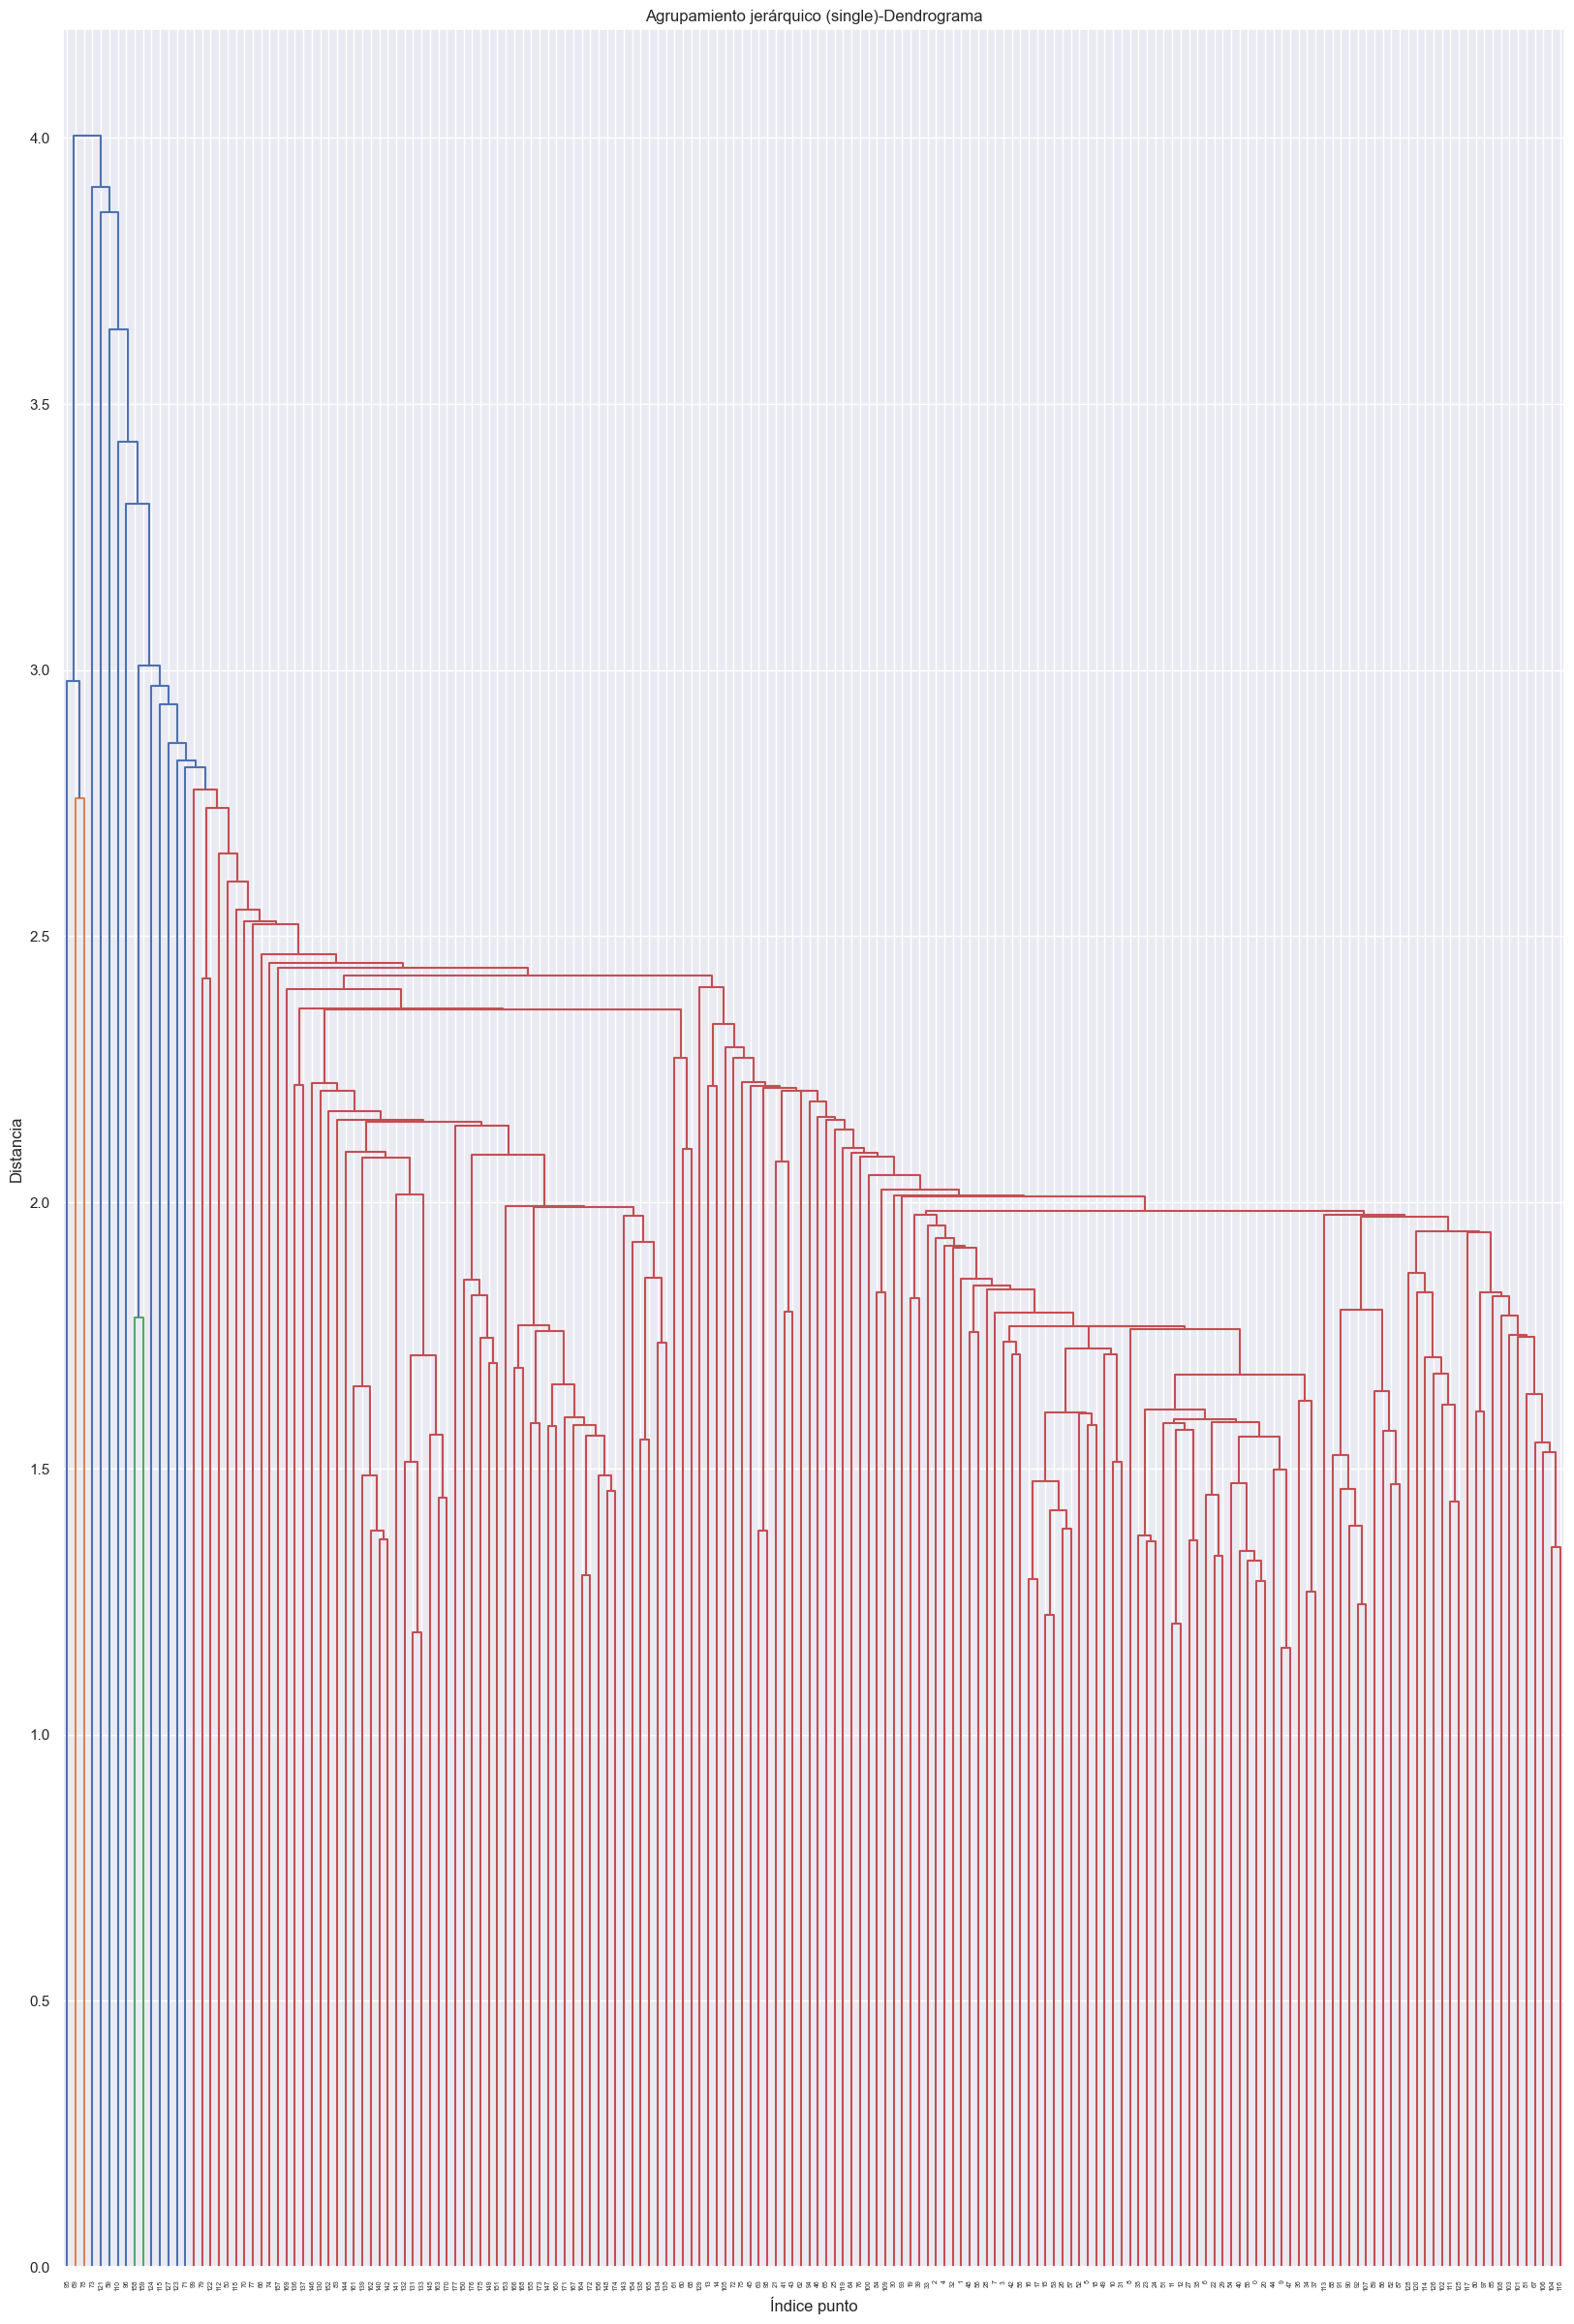

In [77]:
# Dendograma conjunto X_scaled método de medida entre clústeres 'single'
plt.figure(figsize=(20,30))
dendrogram(linkage_single)
plt.title("Agrupamiento jerárquico (single)-Dendrograma")
plt.xlabel("Índice punto")
plt.ylabel("Distancia")
plt.show()

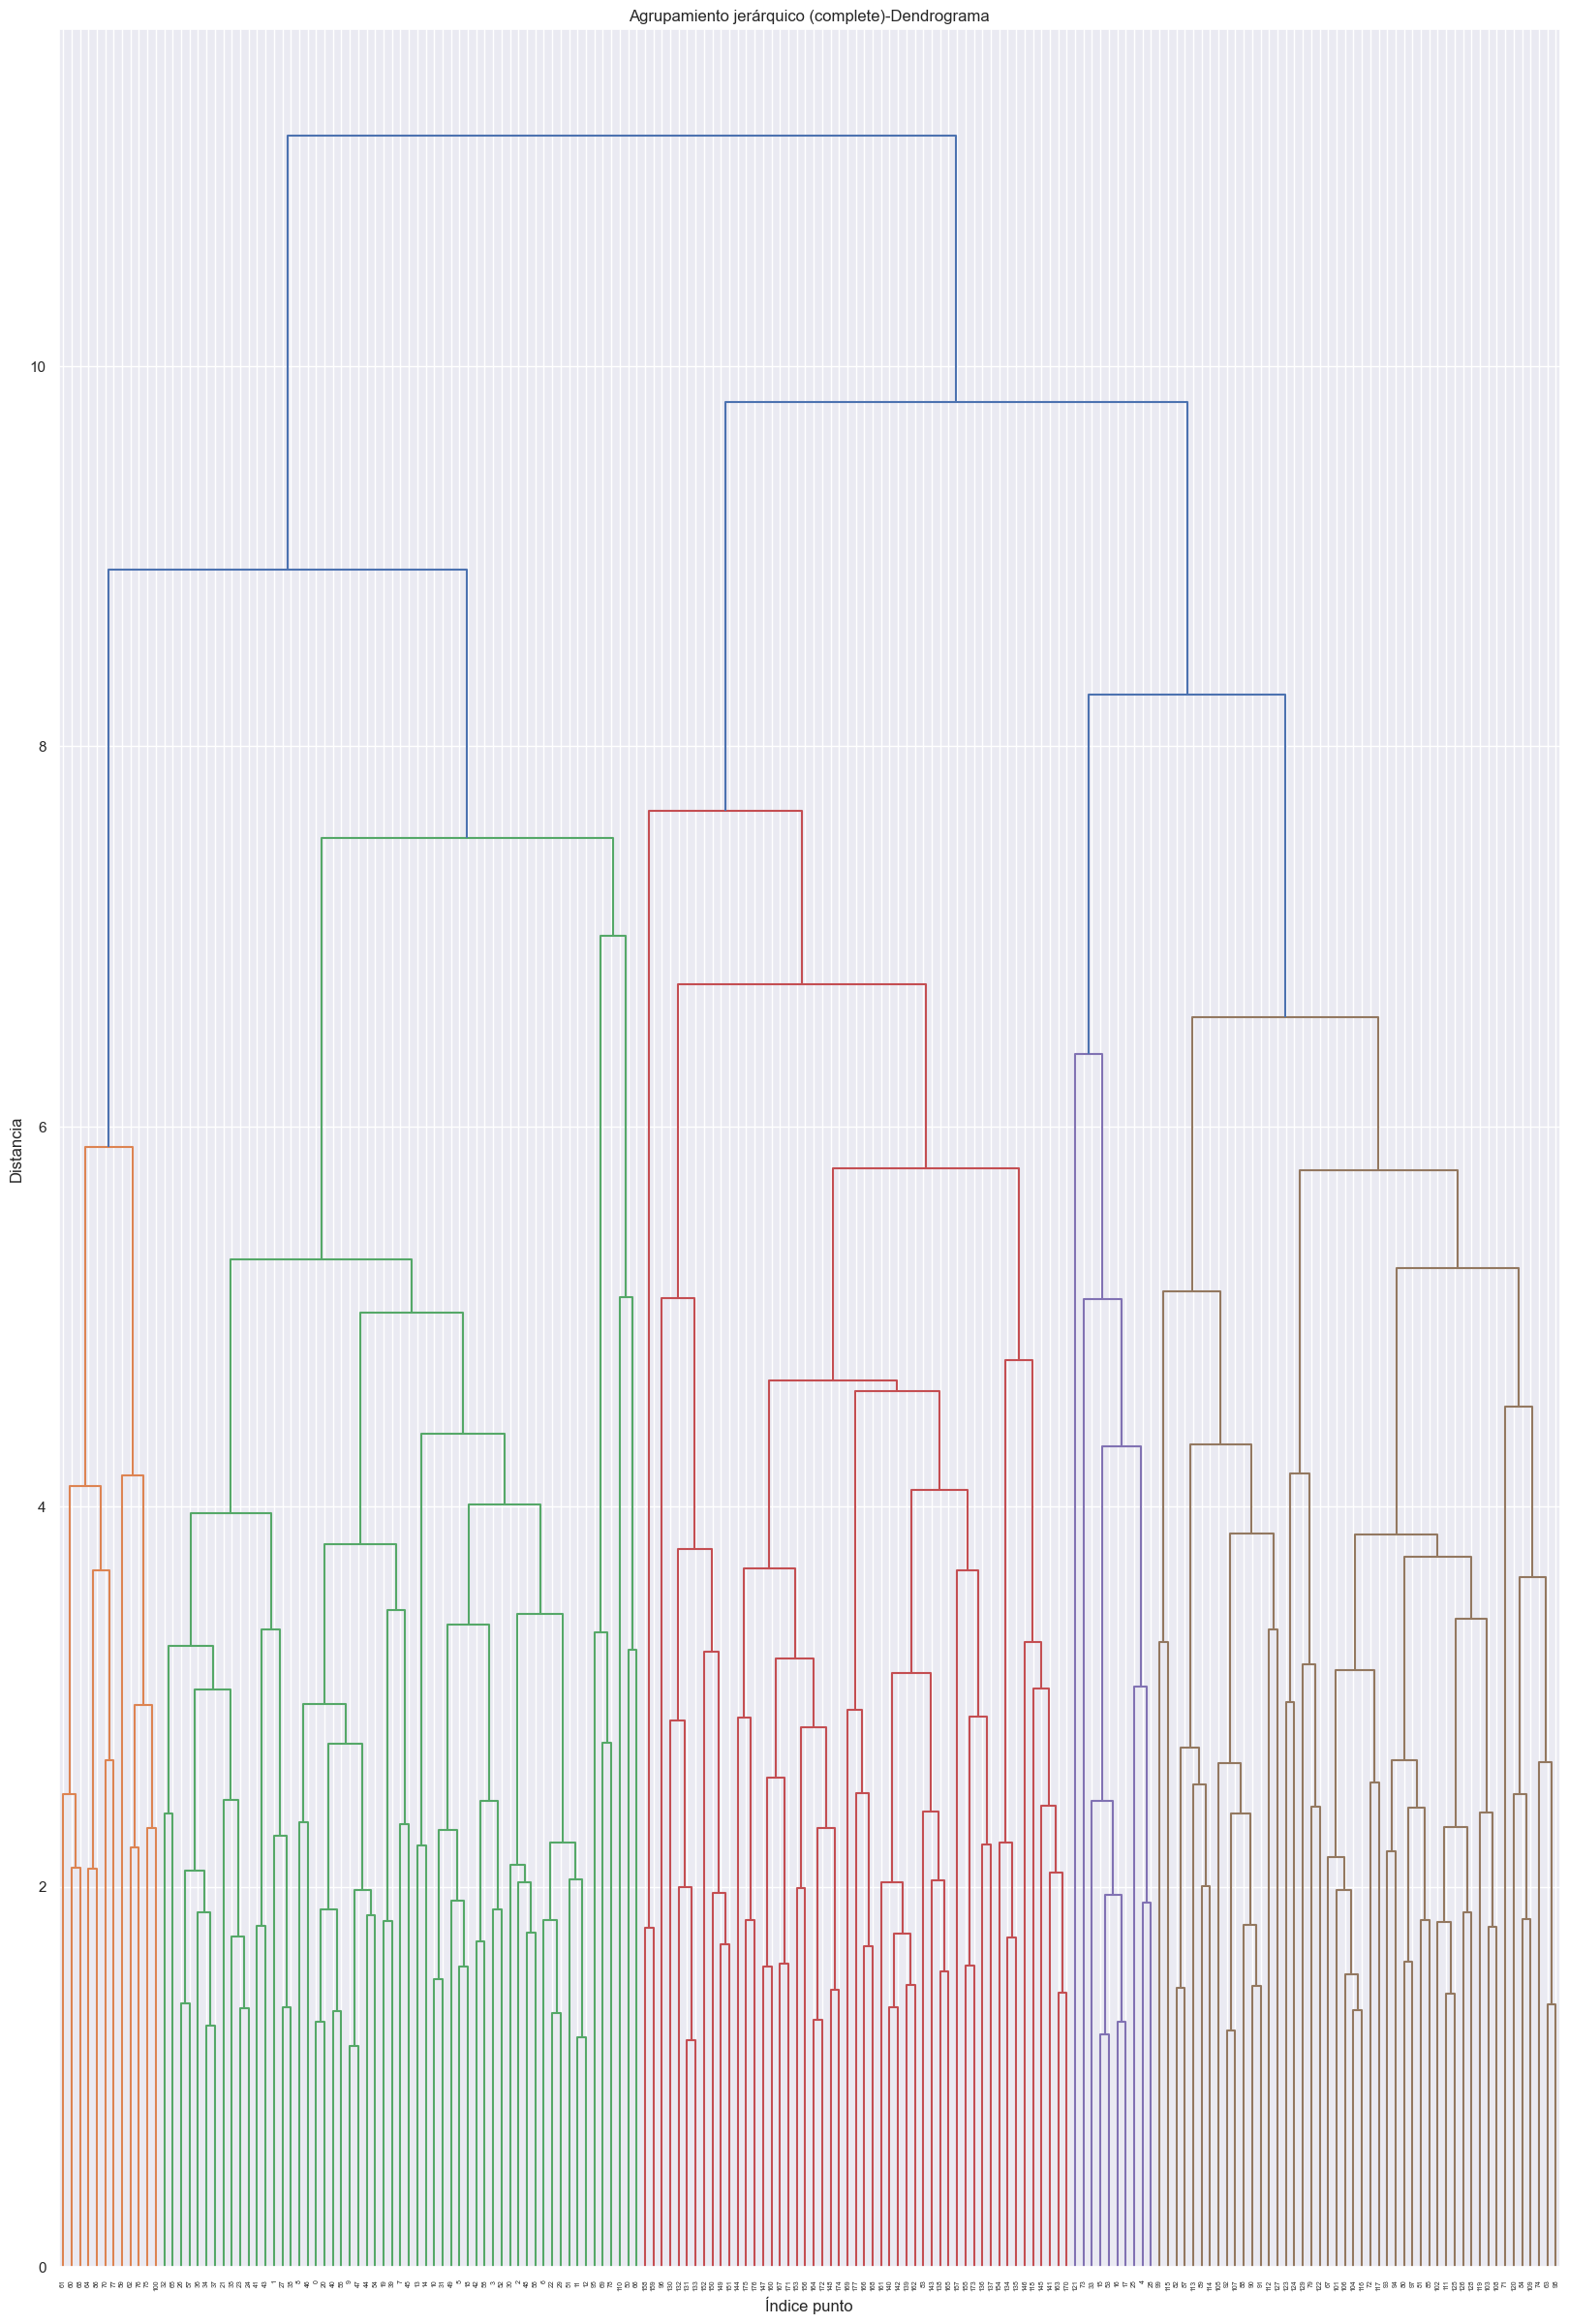

In [78]:
# Dendograma conjunto X_scaled método de medida entre clústeres 'complete'
plt.figure(figsize=(20,30))
dendrogram(linkage_complete)
plt.title("Agrupamiento jerárquico (complete)-Dendrograma")
plt.xlabel("Índice punto")
plt.ylabel("Distancia")
plt.show()

### **REDUCCIÓN DE LA DIMENSIONALIDAD**

### Análisis de componentes principales (PCA)

In [79]:
from sklearn.decomposition import PCA
pca = PCA()
pca

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [80]:
pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [81]:
print(pca.components_.shape)
pca.components_

(13, 13)


array([[ 0.1443294 , -0.24518758, -0.00205106, -0.23932041,  0.14199204,
         0.39466085,  0.4229343 , -0.2985331 ,  0.31342949, -0.0886167 ,
         0.29671456,  0.37616741,  0.28675223],
       [ 0.48365155,  0.22493093,  0.31606881, -0.0105905 ,  0.299634  ,
         0.06503951, -0.00335981,  0.02877949,  0.03930172,  0.52999567,
        -0.27923515, -0.16449619,  0.36490283],
       [-0.20738262,  0.08901289,  0.6262239 ,  0.61208035,  0.13075693,
         0.14617896,  0.1506819 ,  0.17036816,  0.14945431, -0.13730621,
         0.08522192,  0.16600459, -0.12674592],
       [-0.0178563 ,  0.53689028, -0.21417556,  0.06085941, -0.35179658,
         0.19806835,  0.15229479, -0.20330102,  0.39905653,  0.06592568,
        -0.42777141,  0.18412074, -0.23207086],
       [-0.26566365,  0.03521363, -0.14302547,  0.06610294,  0.72704851,
        -0.14931841, -0.10902584, -0.50070298,  0.13685982, -0.07643678,
        -0.17361452, -0.10116099, -0.1578688 ],
       [ 0.21353865,  0.536813

In [82]:
'''
En el Análisis de Componentes Principales (PCA), la "Varianza Explicada" se refiere a la proporción de la varianza total
de los datos originales que cada componente principal logra capturar. La varianza explicada nos indica cuánta información 
de los datos originales se mantiene en cada componente.
'''
pca.explained_variance_ratio_*100

array([36.1988481 , 19.20749026, 11.12363054,  7.06903018,  6.56329368,
        4.93582332,  4.23867932,  2.68074895,  2.2221534 ,  1.93001909,
        1.73683569,  1.29823258,  0.79521489])

range(1, 14)


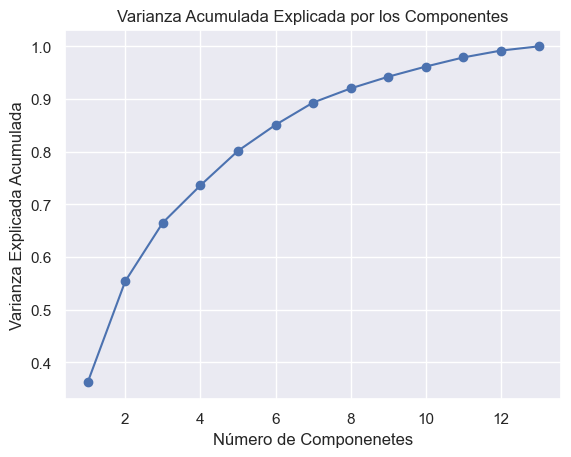

In [83]:
#Gráfico de la varianza acumulada
'''
En este gráfico, podemos ver que la mayor parte de la información (varianza) está contenida en las primeras componentes.
Por ejemplo, podríamos decidir utilizar solo las primeras 5 o 6 componentes si juntas explican más del 80% de la varianza. 
'''
num_varianzas = len(pca.explained_variance_ratio_)  # lista con el porcentaje de varianza de cada variable del conjunto
num_varianzas_acum = pca.explained_variance_ratio_.cumsum() # lista con las varianzas acumuladas. Suma acumulada de las varianzas
num_componentes_desde_1 = range(1,len(pca.explained_variance_ratio_) + 1) # lista de componentes COMENZANDO DESDE 1
print(num_componentes_desde_1)

plt.plot(num_componentes_desde_1,
         num_varianzas_acum,
         marker='o')

plt.title('Varianza Acumulada Explicada por los Componentes')
plt.xlabel('Número de Componenetes')
plt.ylabel('Varianza Explicada Acumulada')
plt.show()

In [84]:
# Con 4 componentes tenemos explicada cerca del 80% de la varianza del conjunto de datos
# Instanciamos un objeto pca con 4 componentes
pca4 = PCA(n_components=4)
pca4

,n_components,4
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [85]:
pca4.fit(X_scaled) # entrenamos el objeto pca4 con los datos del conjunto escalado

,n_components,4
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [86]:
# definimos un dataframe en el que se visualize claramente la relación entre los componentes pca y los atributos (predictivos) del conjunto original
df_pca4 = pd.DataFrame(data=pca4.components_,    # coeficientes para obtener cada componente pca en función de los atributos originales 
                       columns=X.columns.values, # extraemos los nombres de los atributos originales del conjunto X definido al inicio del cuaderno
                       index=["componente 1", "componente 2", "componente 3", "componente 4"]) # definimos los índices como c/u de las componentes pca
df_pca4

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
componente 1,0.144329,-0.245188,-0.002051,-0.239320,0.141992,0.394661,0.422934,-0.298533,0.313429,-0.088617,0.296715,0.376167,0.286752
componente 2,0.483652,0.224931,0.316069,-0.010591,0.299634,0.065040,-0.003360,0.028779,0.039302,0.529996,-0.279235,-0.164496,0.364903
componente 3,-0.207383,0.089013,0.626224,0.612080,0.130757,0.146179,0.150682,0.170368,0.149454,-0.137306,0.085222,0.166005,-0.126746
componente 4,-0.017856,0.536890,-0.214176,0.060859,-0.351797,0.198068,0.152295,-0.203301,0.399057,0.065926,-0.427771,0.184121,-0.232071


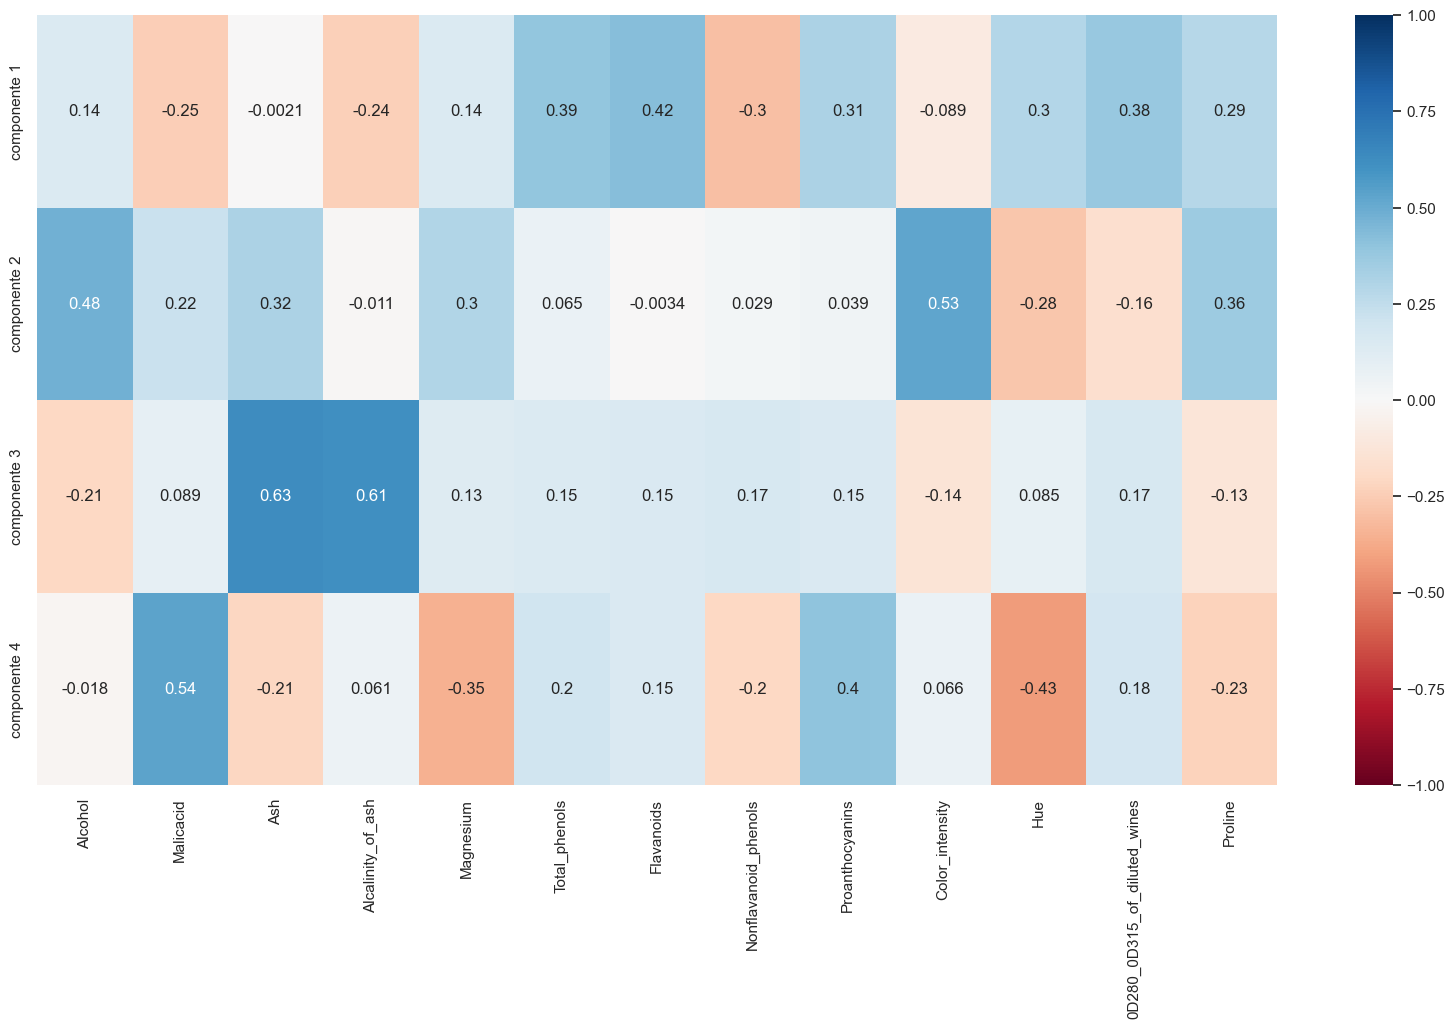

In [87]:
# la misma información anterior en formato mapa de calor
plt.figure(figsize=(20,10))
mapa = sns.heatmap(df_pca4,
                  annot = True,
                  cmap = 'RdBu',
                  vmax=1,
                  vmin=-1)

In [88]:
# Obtenemos un nuevo dataframe en el que los atributos son los 4 componentes pca
X_scaled_pca4= pca4.transform(X_scaled)
df_pca4 = pd.DataFrame(X_scaled_pca4, 
                      columns=['PC0', 'PC1', 'PC2', 'PC3'])
df_pca4

,PC0,PC1,PC2,PC3
0,3.316751,1.443463,-0.165739,-0.215631
1,2.209465,-0.333393,-2.026457,-0.291358
2,2.516740,1.031151,0.982819,0.724902
3,3.757066,2.756372,-0.176192,0.567983
4,1.008908,0.869831,2.026688,-0.409766
...,...,...,...,...
173,-3.370524,2.216289,-0.342570,1.058527
174,-2.601956,1.757229,0.207581,0.349496
175,-2.677839,2.760899,-0.940942,0.312035
176,-2.387017,2.297347,-0.550696,-0.688285


## **K-means con PCA**

In [89]:
# Determinamos el número de clústeres con la nuevas componentes pca
inercias = []
n_clusters = range(1,11)
for n in n_clusters:
    print(f'Evaluando {n} clústeres')
    km = KMeans(n_clusters=n,
           init='k-means++',
           n_init='auto',
           max_iter=300,
           tol=0.0001,
           random_state=10,
           algorithm='lloyd'
           )
    km.fit(X_scaled_pca4)
    inercias.append(km.inertia_)

Evaluando 1 clústeres
Evaluando 2 clústeres
Evaluando 3 clústeres
Evaluando 4 clústeres
Evaluando 5 clústeres
Evaluando 6 clústeres
Evaluando 7 clústeres
Evaluando 8 clústeres
Evaluando 9 clústeres
Evaluando 10 clústeres


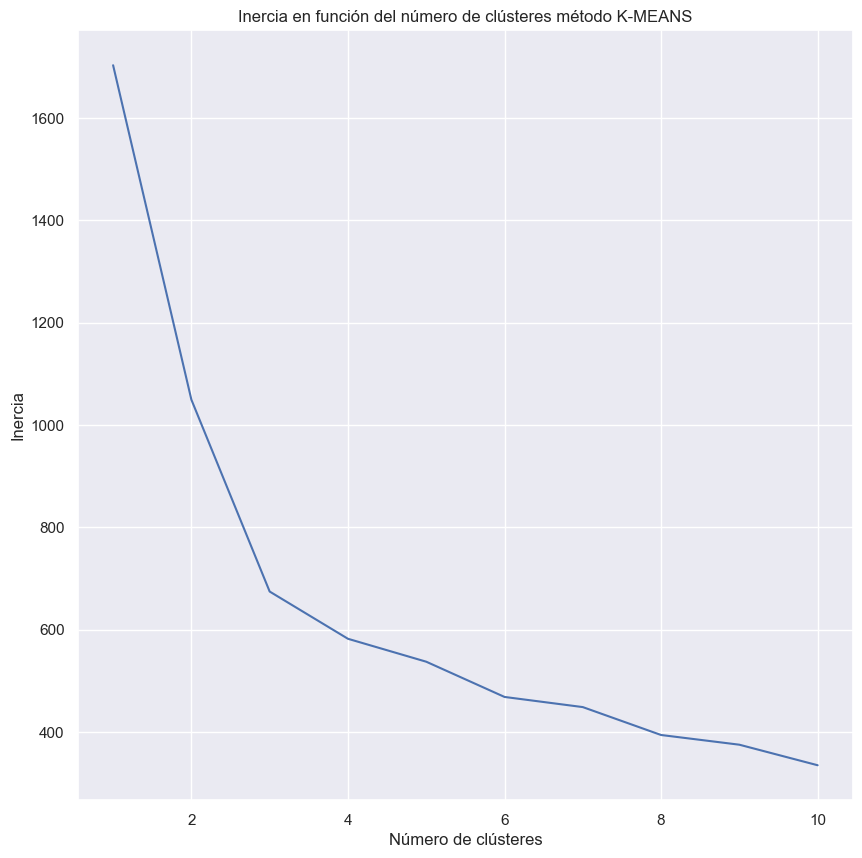

In [90]:
plt.figure(figsize=(10,10))
plt.plot(n_clusters, inercias)
plt.title('Inercia en función del número de clústeres método K-MEANS')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.show()

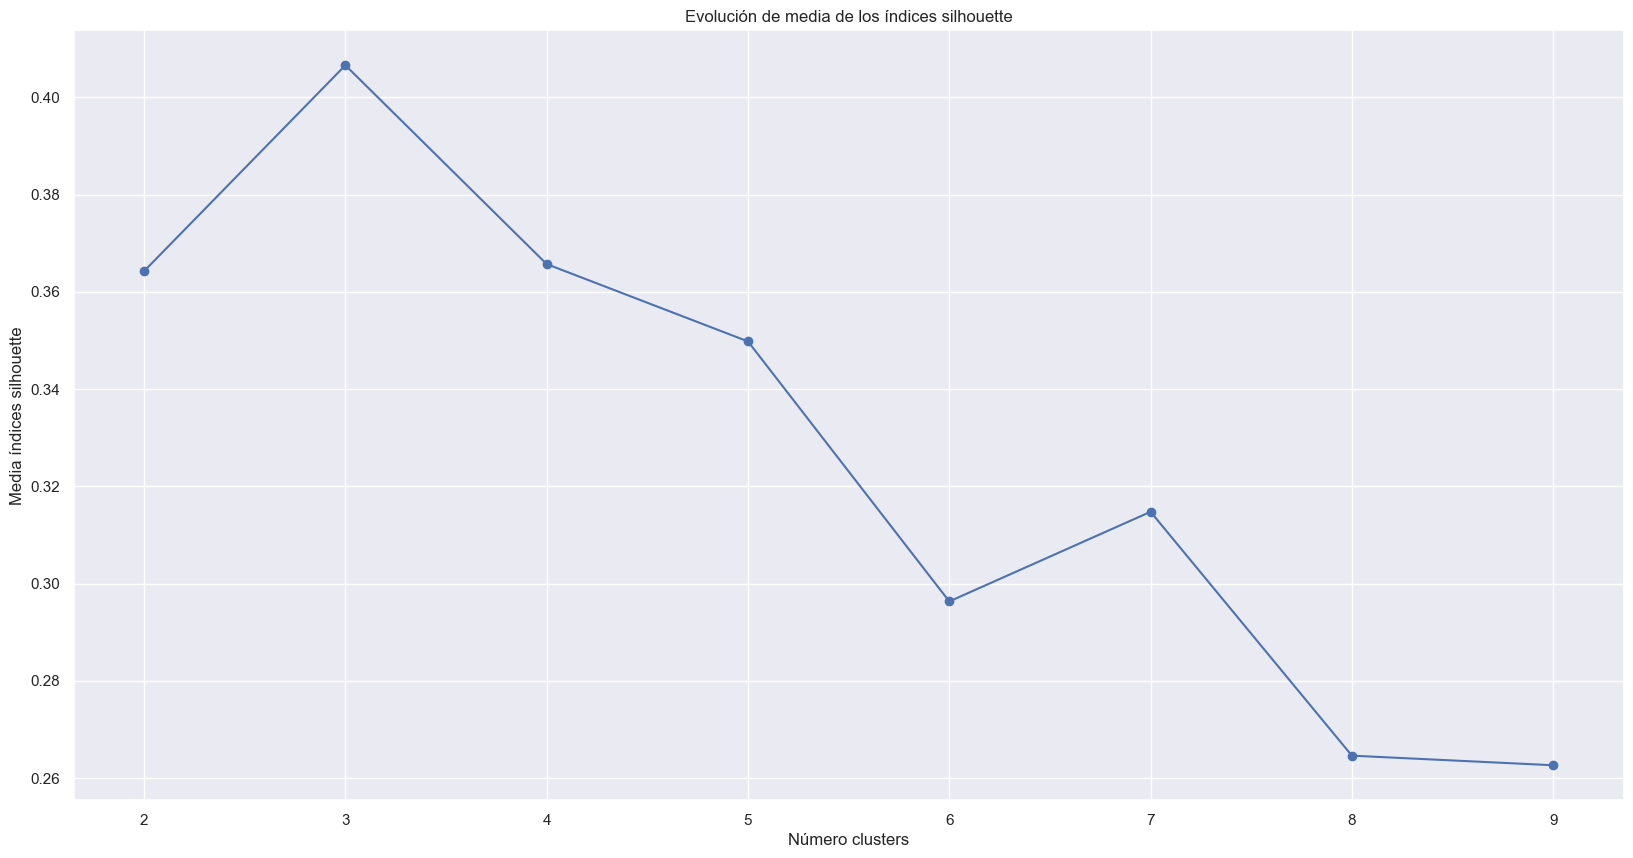

In [91]:
from sklearn.metrics import silhouette_samples, silhouette_score
# Método silhouette para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(2, 10)
valores_medios_silhouette = []

for n_clusters in range_n_clusters:
    km = KMeans(
                 init='k-means++',
                 n_clusters   = n_clusters, 
                 n_init       = 'auto', 
                 max_iter=300,
                 tol=0.0001,
                 random_state = 123,
                 algorithm='lloyd'
                )
    cluster_labels = km.fit_predict(X_scaled_pca4)
    silhouette_avg = silhouette_score(X_scaled_pca4, cluster_labels)
    valores_medios_silhouette.append(silhouette_avg)
    
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.plot(range_n_clusters, valores_medios_silhouette, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');


Para 2 clústeres el silhouette_score es 0.3642508323945743 

El tamaño del cluster 0 es: 65

El tamaño del cluster 1 es: 113


Para 3 clústeres el silhouette_score es 0.406596910894866 

El tamaño del cluster 0 es: 51

El tamaño del cluster 1 es: 65

El tamaño del cluster 2 es: 62


Para 4 clústeres el silhouette_score es 0.3571637972738213 

El tamaño del cluster 0 es: 49

El tamaño del cluster 1 es: 29

El tamaño del cluster 2 es: 45

El tamaño del cluster 3 es: 55


Para 5 clústeres el silhouette_score es 0.2898236011753109 

El tamaño del cluster 0 es: 22

El tamaño del cluster 1 es: 29

El tamaño del cluster 2 es: 43

El tamaño del cluster 3 es: 55

El tamaño del cluster 4 es: 29



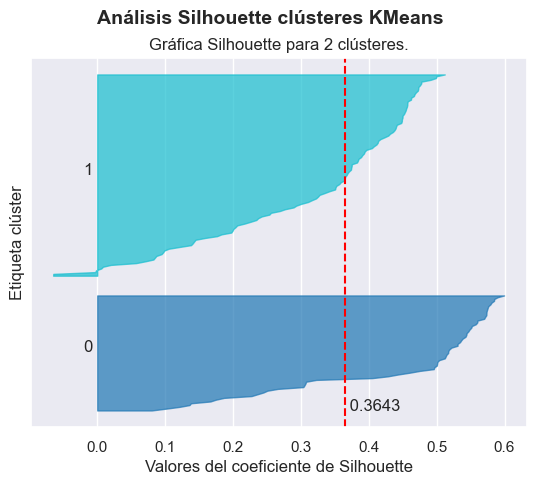

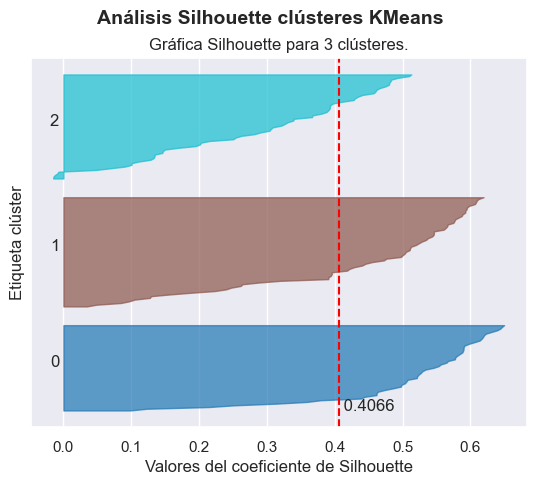

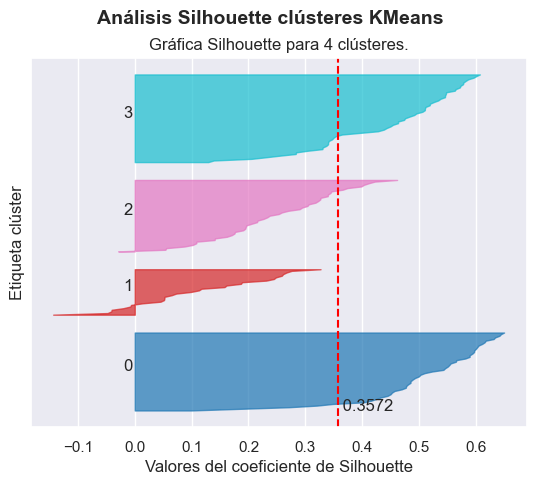

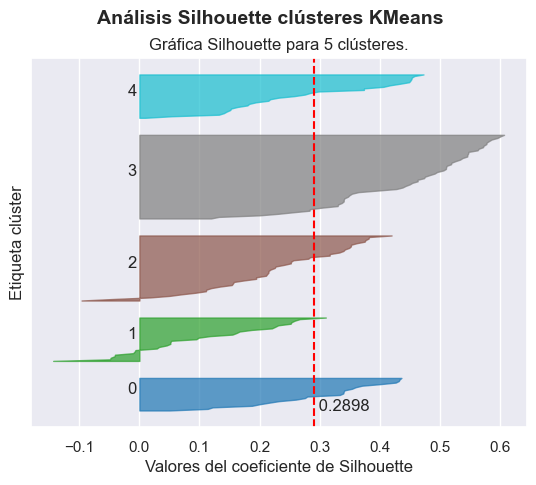

In [92]:
import matplotlib.cm as cm
rango_n_clusteres = [2, 3, 4, 5]

for n_clusteres in rango_n_clusteres: #Para 2,3,4,5 clústeres

    fig, ax = plt.subplots()  # fig es el lienzo de dibujo, donde estrán cada uno de los conj. de ejes ax
    # configuramos el eje Y: yticks son marcas o números del eje Y (0, 1, 2, …).
    # La lista vacía [] significa no muestrar marcas ni números en el eje Y    
    ax.set(yticks = []) 
  
    
    km = KMeans(n_clusters=n_clusteres, random_state=10, n_init="auto")
    #predecimos etiquetas de clúster a cada punto del dataset escalado
    cluster_labels = km.fit_predict(X_scaled_pca4) 
    
      
    sample_silhouette_values = silhouette_samples(X_scaled_pca4, cluster_labels)  #coeficiente de silhouette instancias (puntos) del dataset
    
    silhouette_medio = silhouette_score(X_scaled_pca4, cluster_labels)  # calculamos la media de los cofecientes silhouette para un número de n_clusteres
    print(
        f"\nPara {n_clusteres} clústeres el silhouette_score es {silhouette_medio} \n"
    )

    #DIBUJAMOS LAS GRÁFICAS DE CLUSTERS-COEFICIENTES DE SILHOUETTE-SILHOUETTE SCORE
    y_inf = 0  #limite interior en el eje y para dibujar el clúster i
    for i in range(n_clusteres):#para cada uno de cada conjunto de clusters (2 clústers, se ejecuta 2 veces con valores 0,1..., etc)
       
        cluster_i_silhouette_values = sample_silhouette_values[cluster_labels == i]#valores coeficiente silhouette para el cluster i

        cluster_i_silhouette_values.sort()#ordenamos los valores de los coeficientes del clúster i

        size_cluster_i = len(cluster_i_silhouette_values) #tamaño del conjunto de puntos del clúster con etiqueta i 

        print(f'El tamaño del cluster {i} es: {size_cluster_i}\n')

        # y_upper = y_lower + número de puntos del clúster i
        y_sup = y_inf + size_cluster_i #limite superior en el eje y para dibujar el clúster i.
        #elegimos un color i del mapa de colores tab10 para cada clúster
        cmap = plt.get_cmap("tab10", n_clusteres)
        color = cmap(i)  # color i-ésimo

        # para cada “fila” en el eje y se dibuja una barra horizontal desde x=0 hasta el valor silhouette.
        # np.arange(y_lower, y_upper) no incluye y_upper, por eso salen justo y_upper - y_lower elementos, que es size_cluster_i.
        ax.fill_betweenx(  # en el conjunto de ejes ax
            np.arange(y_inf, y_sup), # valores del eje y donde se dibuja el bloque. genera size_cluster_i posiciones (una por valor silhouette).
                                         # Ejemplo: si y_lower=40 y y_upper=60, produce: 40, 41, 42, …, 59 (uno por cada punto del cluster)
            0,                           # límite izquierdo en el eje x (arranca desde 0)
            cluster_i_silhouette_values, # límite derecho en el eje x (el valor silhouette de cada punto)
            facecolor=color,             # relleno
            edgecolor=color,             # color borde
            alpha=0.7,                   # transparencia
        )
   
        ax.text(-0.02, y_inf + 0.5 * size_cluster_i, str(i)) # etiqueta de cada clúster
        y_inf = y_sup + 10 # deja un hueco de 10 entre clústeres    

    ax.set_title(f"Gráfica Silhouette para {n_clusteres} clústeres.")
    ax.set_xlabel("Valores del coeficiente de Silhouette")
    ax.set_ylabel("Etiqueta clúster")
    
    # Línea vertical para indicar el valor de coeficiente de Silhoutte del dataset   
    ax.axvline(x=silhouette_medio, color="red", linestyle="--")
    ax.text(silhouette_medio, 0, f' {silhouette_medio:.4f}')  # etiqueta de cada valor de silhoutte medio (para un número n_clústeres) 
    plt.suptitle(
        "Análisis Silhouette clústeres KMeans",
        fontsize=14,
        fontweight="bold"
    )

plt.show()

## **Dendrograma con PCA**

In [93]:
linkage_complete = linkage(X_scaled_pca4, method="complete",  metric="euclidean")


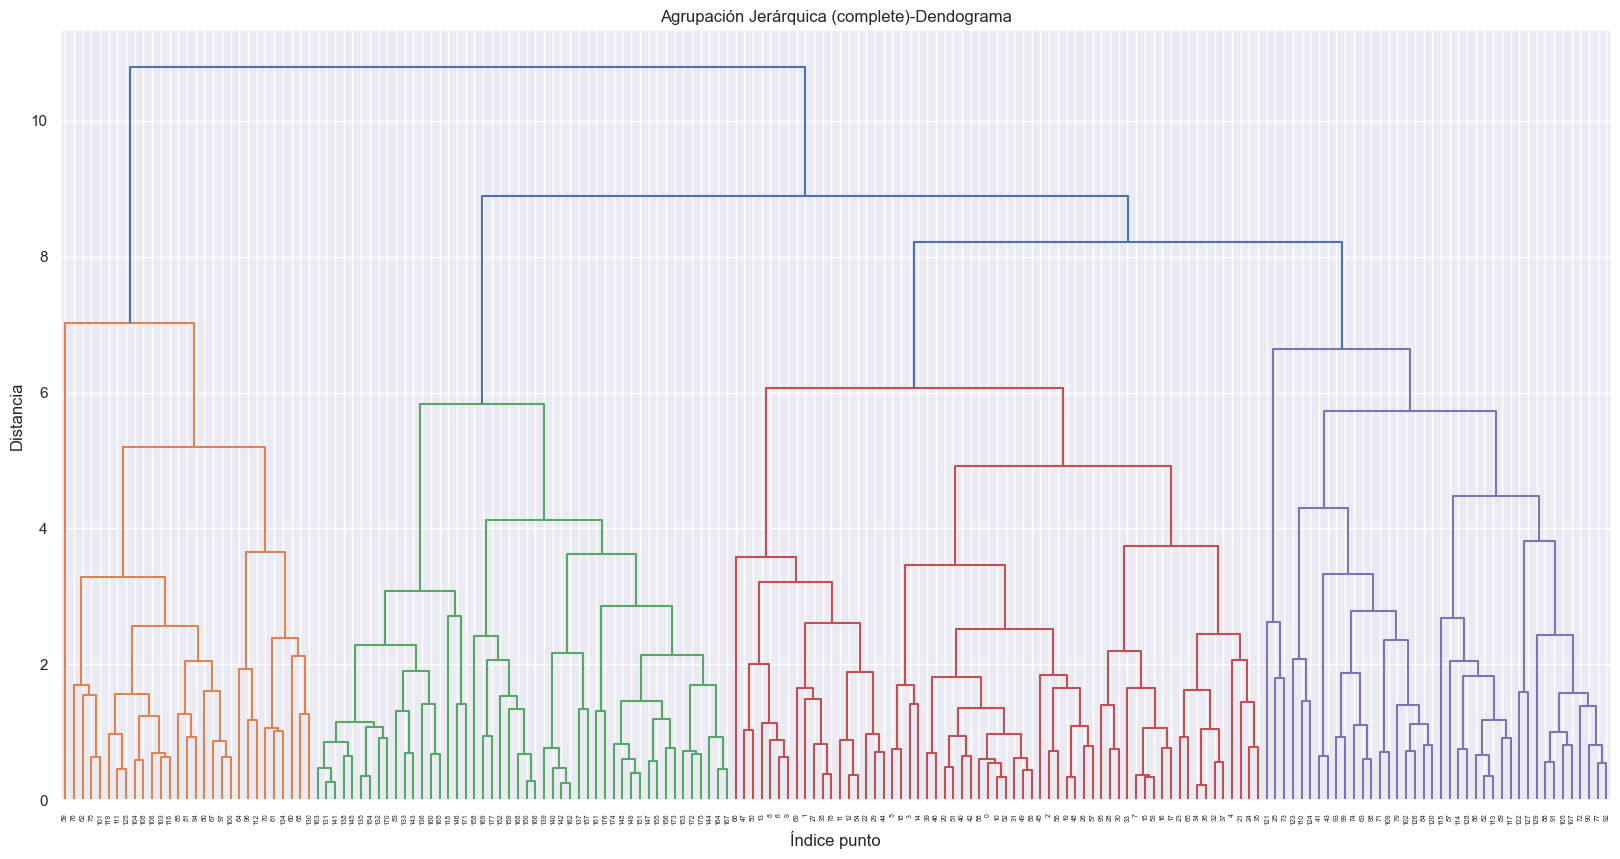

In [94]:
fig = plt.figure(figsize=(20,10))
dendrogram(linkage_complete)
plt.title("Agrupación Jerárquica (complete)-Dendograma")
plt.xlabel("Índice punto")
plt.ylabel("Distancia")
plt.show()

## **Gráfica 2D de clústeres**

In [95]:
# El anterior análisi nos lleva a la conclusión de que el conjunto X_scaled_pca4 se encuentra agrupado en 3 clústeres
# Instanciamos un objeto k-means con 3 clústeres
km = KMeans(
            init='k-means++',
            n_clusters   = 3, 
            n_init       = 'auto', 
            max_iter=300,
            tol=0.0001,
            random_state = 123,
            algorithm='lloyd'
            )

In [96]:
# las etiquetas para estos clústeres las encontramos:
cluster_labels = km.fit_predict(X_scaled_pca4)
print(cluster_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 0 1 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [97]:
# construimos un nuevo dataframe para llevar a cabo análisis gráfico del conjunto X_scaled_pca4 
df_scaled_pca4 = pd.DataFrame(X_scaled_pca4, 
                              columns=['PCA0', 'PCA1', 'PCA2', 'PCA3']) # componenetes principales
df_scaled_pca4['labels'] = cluster_labels
df_scaled_pca4

,PCA0,PCA1,PCA2,PCA3,labels
0,3.316751,1.443463,-0.165739,-0.215631,1
1,2.209465,-0.333393,-2.026457,-0.291358,1
2,2.516740,1.031151,0.982819,0.724902,1
3,3.757066,2.756372,-0.176192,0.567983,1
4,1.008908,0.869831,2.026688,-0.409766,1
...,...,...,...,...,...
173,-3.370524,2.216289,-0.342570,1.058527,2
174,-2.601956,1.757229,0.207581,0.349496,2
175,-2.677839,2.760899,-0.940942,0.312035,2
176,-2.387017,2.297347,-0.550696,-0.688285,2


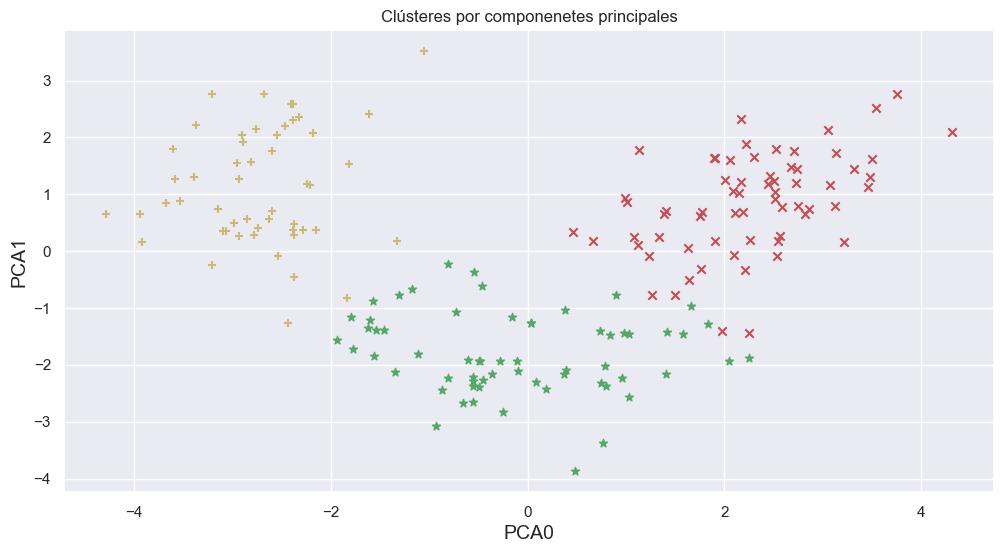

In [98]:
# Representación gráfica de tres componentes de X_scaled_pca4 de clases 0, 1 y 2
sns.set(style="darkgrid")
plt.figure(figsize=(12, 6))
plt.scatter(df_scaled_pca4['PCA0'][df_scaled_pca4['labels'] == 0],
            df_scaled_pca4['PCA1'][df_scaled_pca4['labels'] == 0],
            c="g",
            marker="*")

plt.scatter(df_scaled_pca4['PCA0'][df_scaled_pca4['labels'] == 1],
            df_scaled_pca4['PCA1'][df_scaled_pca4['labels'] == 1],
            c="r",
            marker="x")

plt.scatter(df_scaled_pca4['PCA0'][df_scaled_pca4['labels'] == 2],
            df_scaled_pca4['PCA1'][df_scaled_pca4['labels'] == 2],
            c="y",
            marker="+")

plt.xlabel('PCA0', fontsize=14)
plt.ylabel('PCA1', fontsize=14)
plt.title('Clústeres por componenetes principales')
plt.show()

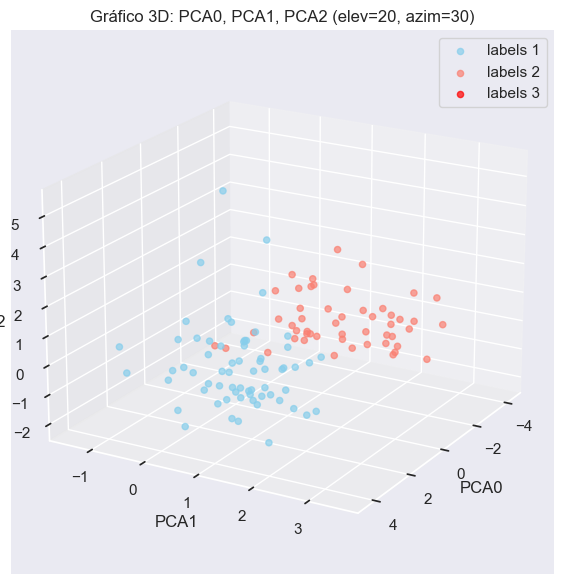

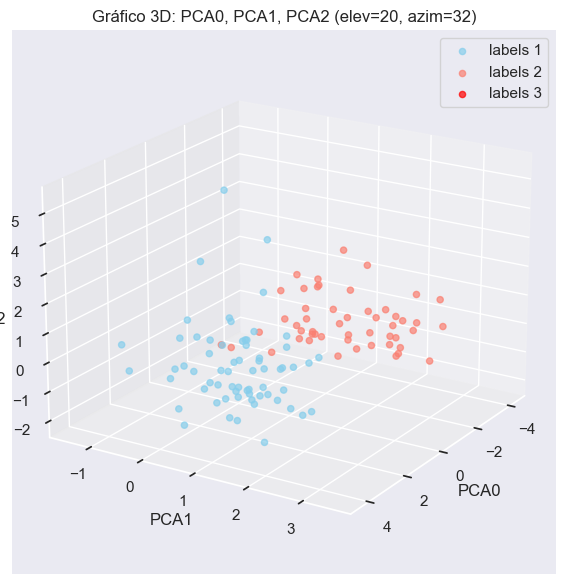

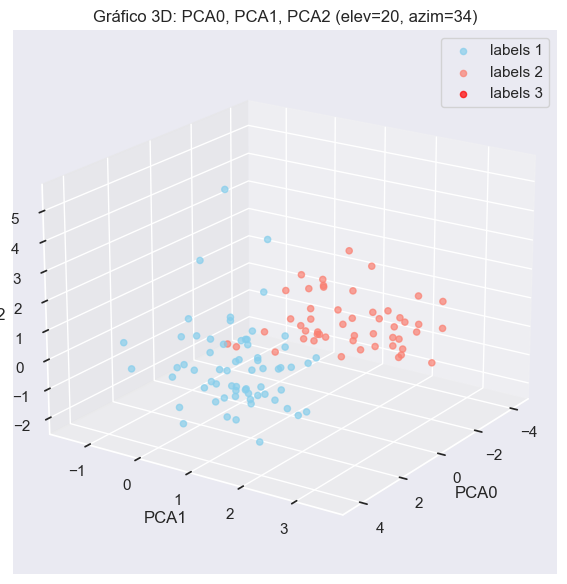

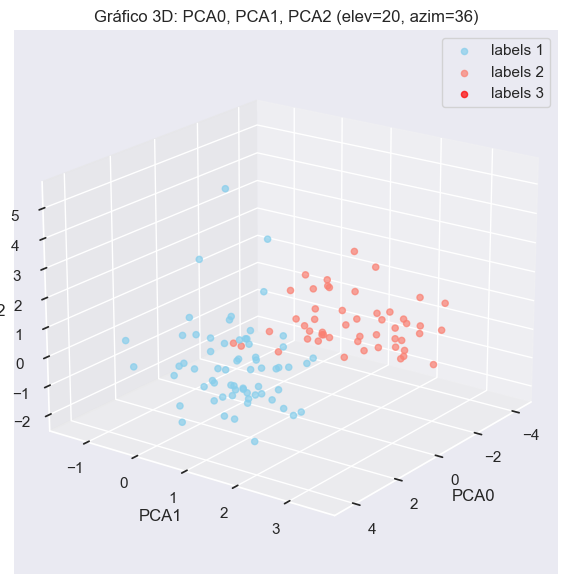

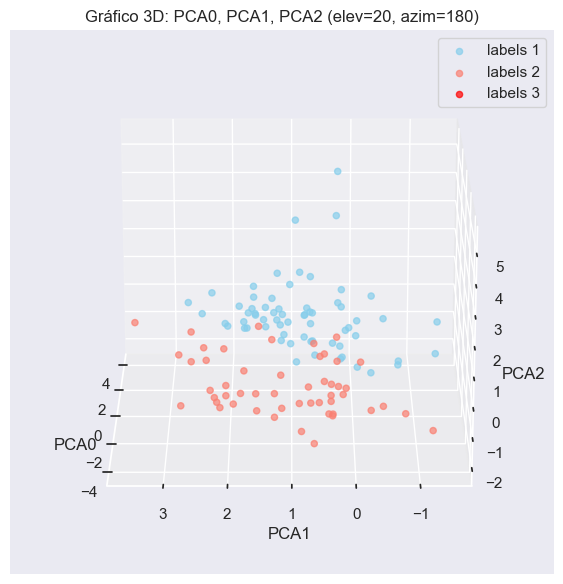

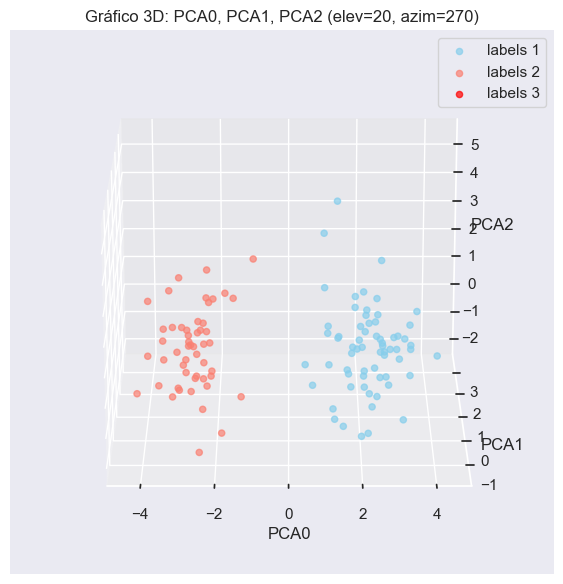

In [ ]:
# Gráfico 3D desde diferentes perspectivas 
def grafico_3d(df, x_var, y_var, z_var, elev, azim):
    """
    Dibuja un gráfico 3D de tres variables numéricas con una orientación definida.
    Parámetros:
    df    : DataFrame con los datos
    x_var : nombre de la variable para el eje X
    y_var : nombre de la variable para el eje Y
    z_var : nombre de la variable para el eje Z
    elev  : ángulo de elevación de la cámara
    azim  : ángulo de rotación (azimut)
    """
    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes(projection='3d')
    plt.title(f'Gráfico 3D: {x_var}, {y_var}, {z_var} (elev={elev}, azim={azim})')
    # Clase 1
    x0 = df[df['labels'] == 1][x_var]
    y0 = df[df['labels'] == 1][y_var]
    z0 = df[df['labels'] == 1][z_var]
    ax.scatter3D(x0, y0, z0, color='skyblue', alpha=0.7, label='labels 1')
    # Clase 2
    x1 = df[df['labels'] == 2][x_var]
    y1 = df[df['labels'] == 2][y_var]
    z1 = df[df['labels'] == 2][z_var]
    ax.scatter3D(x1, y1, z1, color='salmon', alpha=0.7, label='labels 2')
    # Clase 3
    x1 = df[df['labels'] == 3][x_var]
    y1 = df[df['labels'] == 3][y_var]
    z1 = df[df['labels'] == 3][z_var]
    ax.scatter3D(x1, y1, z1, color='red', alpha=0.7, label='labels 3')

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_zlabel(z_var)
    ax.legend()
    # Cambiar orientación
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()



var1, var2 , var3 = ('PCA0', 'PCA1', 'PCA2')


# Gráfico 1
grafico_3d(df_scaled_pca4, var1, var2, var3, elev=20, azim=30)

# Gráfico 2
grafico_3d(df_scaled_pca4, var1, var2, var3, elev=20, azim=32)

# Gráfico 3
grafico_3d(df_scaled_pca4, var1, var2, var3 , elev=20, azim=34)

# Gráfico 4
grafico_3d(df_scaled_pca4,  var1, var2, var3 ,elev=20, azim=36)

# Gráfico 5
grafico_3d(df_scaled_pca4, var1, var2, var3, elev=20, azim=180)

# Gráfico 6
grafico_3d(df_scaled_pca4, var1, var2, var3, elev=20, azim=270)

